# DI-Gesture Model Training and Comparison


# Experiment Setup

This notebook compares nine gesture-recognition models. The tables below show the final settings used in `full` mode after all model-specific overrides are applied.

## 1. Model Training Parameters

All models use the AdamW optimizer.

| Model | Epochs | Batch | Learning Rate | Weight Decay | Label Smoothing | Warm-up | Schedule |
|---|---:|---:|---:|---:|---:|---:|---|
| CRNN Baseline | 20 | 64 | `1e-4` | `1e-4` | `0.00` | 0 | Constant |
| CNN + Transformer | 40 | 32 | `4e-4` | `3e-2` | `0.03` | 5 | Cosine |
| TRANS-CNN-1D | 40 | 32 | `1e-4` | `1e-4` | `0.03` | 5 | Cosine |
| LPVT-Full | 30 | 6 | `2e-4` | `5e-2` | `0.05` | 6 | Cosine |
| MobileViT (Project Full) | 30 | 6 | `2e-4` | `5e-2` | `0.05` | 6 | Cosine |
| MobileViT (Paper Teacher) | 40 | 24 | `3e-4` | `3e-2` | `0.03` | 5 | Cosine |
| MobileViT (Paper Student + KD) | 40 | 32 | `3e-4` | `2e-2` | `0.00` | 5 | Cosine |
| MobileViT (External Frozen) | 20 | 2 | `1e-4` | `1e-4` | `0.03` | 0 | Constant |
| TimeSformer-Full | 30 | 2 | `1.5e-4` | `5e-2` | `0.05` | 6 | Cosine |

## 2. Model-Specific Options

| Model Group | Motion Input | Augmentation | Gradient Clip | Additional Setting |
|---|---|---|---:|---|
| CRNN Baseline | No | No | None | Embed `128`; LSTM hidden size `192` |
| CNN + Transformer | Yes | Yes | `1.0` | Embed `128`; two layers; four attention heads |
| TRANS-CNN-1D | Yes | No | `0.25` | Embed `128`; four heads; GroupNorm temporal CNN |
| LPVT-Full | Yes | Yes | `1.0` | Channels `48-96-192-256`; three layers; eight heads |
| MobileViT (Project Full) | Yes | Yes | `1.0` | Channels `32-64-128-192`; three layers; six heads |
| Paper Teacher | Yes | Yes | `1.0` | Fusion dimension `64`; four heads; dual DRAI branches |
| Paper Student + KD | Yes | Yes | `1.0` | Fusion dimension `32`; two heads; temperature `4.0`; KD alpha `0.5` |
| External MobileViT | No | No | `1.0` | Frozen `apple/mobilevit-small` backbone; temporal embed `256` |
| TimeSformer-Full | Yes | Yes | `1.0` | Patch `8`; embed `256`; depth `4`; eight heads |

## 3. Shared Experiment Settings

| Setting | Value |
|---|---|
| Run mode | `full` |
| Device | Apple MPS |
| Random seed | `21` |
| Input sequence | `32` DRAI frames of size `32 x 32` |
| Number of classes | `7` |
| Training environments | `e2`, `e3`, `e4` |
| Validation environment | `e1` |
| Test environment | `e6` |





## 1. Imports and Configuration

The notebook reloads the local modules and prints the active configuration. 

In [14]:
from __future__ import annotations

from pathlib import Path
import importlib
import sys

import pandas as pd
from IPython.display import display
from sklearn.preprocessing import LabelEncoder

# Add the experiment module directory to the notebook import path.
EXPERIMENT_DIR = Path("/Users/blue/Desktop/Practicum/code/experiment1")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

# Reload local modules so execution reflects the current source files.
import experiment_config
import data_pipeline
import training_tools
import model_zoo
import training_loop
import reporting

for module in [
    experiment_config,
    data_pipeline,
    training_tools,
    model_zoo,
    training_loop,
    reporting,
]:
    importlib.reload(module)

# Configuration is centralized in experiment_config.py.
from experiment_config import ACTION_NAMES, CONFIG, MODEL_DISPLAY_NAMES, print_config_summary

# Data, model, training, and reporting code is split by responsibility.
from data_pipeline import make_loader, prepare_splits, set_seed, summarize_split
from model_zoo import model_registry_frame
from reporting import build_report_tables, display_report_tables, plot_result_figures
from training_loop import build_model, run_experiment

# Apply the configured seed and validate the dataset path before execution.
set_seed(CONFIG.seed)
if not CONFIG.data_path.exists():
    raise FileNotFoundError(f"Dataset path does not exist: {CONFIG.data_path}")

print_config_summary(CONFIG)


device: mps
torch: 2.0.1
mps_available: True
device_mode: mps
run_mode: full
forward_only: False
transformer_motion_input: True
transformer_augmentation: True
model_full_epochs: {'crnn': 20, 'cnn_transformer': 40, 'trans_cnn_1d': 40, 'lpvt_full': 30, 'mobilevit_full': 30, 'paper_mobilevit_teacher': 40, 'paper_mobilevit_student': 40, 'external_mobilevit_frozen': 20, 'timesformer_full': 30}
paper_kd_teacher_model: paper_mobilevit_teacher
paper_kd_temperature: 4.0
paper_kd_alpha: 0.5
loss_compute_device: cpu
enabled_models: ['crnn', 'cnn_transformer', 'trans_cnn_1d', 'lpvt_full', 'mobilevit_full', 'paper_mobilevit_teacher', 'paper_mobilevit_student', 'external_mobilevit_frozen', 'timesformer_full']
data_path: /Users/blue/NCI/MCD-Gesture_ProcessedDataset
cache_dir: /Users/blue/Desktop/Practicum/code/experiment1/cache
use_run_cache: True
save_run_cache: True
skip_train_if_results_exist: True
resume_from_checkpoint: True
save_checkpoints: True
force_retrain: False
epochs_override: None
smoke

## 2. Data Split

The split is environment-based: train uses `e2/e3/e4`, validation uses `e1`, and test uses `e6`.

In [15]:
# Encode the fixed gesture labels in one consistent order.
label_encoder = LabelEncoder()
label_encoder.fit(ACTION_NAMES)

# Load full or smoke-limited splits according to CONFIG.
(
    train_files,
    train_labels,
    val_files,
    val_labels,
    test_files,
    test_labels,
) = prepare_splits(CONFIG, label_encoder)

# Print a compact class-count check before training.
summarize_split("train", train_labels, label_encoder)
summarize_split("validation", val_labels, label_encoder)
summarize_split("test", test_labels, label_encoder)


train: 13300 samples
{'n': 7600, 'Clockwise': 950, 'Counterclockwise': 950, 'Pull': 950, 'Push': 950, 'SlideLeft': 950, 'SlideRight': 950}
validation: 4900 samples
{'n': 2800, 'Clockwise': 350, 'Counterclockwise': 350, 'Pull': 350, 'Push': 350, 'SlideLeft': 350, 'SlideRight': 350}
test: 3050 samples
{'n': 1400, 'Clockwise': 275, 'Counterclockwise': 275, 'Pull': 275, 'Push': 275, 'SlideLeft': 275, 'SlideRight': 275}


## 3. Data Analysis



In [16]:
# Data analysis module: split balance, environment composition, and sampled DRAI statistics.
from collections import Counter
import re

import numpy as np


def _environment_id(file_name):
    match = re.search(r"_e(\d+)", file_name)
    return int(match.group(1)) if match else None


split_items = [
    ("train", train_files, train_labels),
    ("validation", val_files, val_labels),
    ("test", test_files, test_labels),
]

split_summary_rows = []
class_balance_rows = []
environment_rows = []

for split_name, files, labels in split_items:
    label_names = label_encoder.inverse_transform(labels)
    class_counts = Counter(label_names)
    env_counts = Counter(_environment_id(file_name) for file_name in files)
    per_class_counts = list(class_counts.values())
    split_summary_rows.append(
        {
            "split": split_name,
            "samples": len(files),
            "classes": len(class_counts),
            "min_per_class": min(per_class_counts) if per_class_counts else 0,
            "max_per_class": max(per_class_counts) if per_class_counts else 0,
            "mean_per_class": round(float(np.mean(per_class_counts)), 2) if per_class_counts else 0.0,
            "environment_ids": ", ".join(str(env_id) for env_id in sorted(env_counts) if env_id is not None),
        }
    )
    for class_name in ACTION_NAMES:
        class_balance_rows.append(
            {
                "split": split_name,
                "class": class_name,
                "count": int(class_counts.get(class_name, 0)),
            }
        )
    for env_id, count in sorted(env_counts.items(), key=lambda item: (-1 if item[0] is None else item[0])):
        environment_rows.append({"split": split_name, "environment_id": env_id, "count": int(count)})

SPLIT_SUMMARY_DF = pd.DataFrame(split_summary_rows)
CLASS_BALANCE_DF = pd.DataFrame(class_balance_rows)
ENVIRONMENT_SPLIT_DF = pd.DataFrame(environment_rows)

display(SPLIT_SUMMARY_DF)
display(CLASS_BALANCE_DF.pivot(index="class", columns="split", values="count").reindex(ACTION_NAMES))
display(ENVIRONMENT_SPLIT_DF)

# Sample a small, deterministic subset for DRAI tensor statistics without loading the full dataset.
sample_stat_rows = []
samples_per_class = 2

for split_name, files, labels in split_items:
    label_names = label_encoder.inverse_transform(labels)
    for class_name in ACTION_NAMES:
        class_files = [file_name for file_name, label_name in zip(files, label_names) if label_name == class_name]
        for file_name in class_files[:samples_per_class]:
            frames = np.load(CONFIG.data_path / file_name).astype(np.float32)
            sample_stat_rows.append(
                {
                    "split": split_name,
                    "class": class_name,
                    "file": file_name,
                    "frames": int(frames.shape[0]),
                    "height": int(frames.shape[1]),
                    "width": int(frames.shape[2]),
                    "mean": float(frames.mean()),
                    "std": float(frames.std()),
                    "mean_abs": float(np.abs(frames).mean()),
                    "max_abs": float(np.abs(frames).max()),
                    "nonzero_ratio": float(np.count_nonzero(frames) / frames.size),
                }
            )

DRAI_SAMPLE_STATS_DF = pd.DataFrame(sample_stat_rows)
display(DRAI_SAMPLE_STATS_DF.head(12))
display(
    DRAI_SAMPLE_STATS_DF.groupby("split")[["frames", "mean_abs", "max_abs", "nonzero_ratio"]]
    .agg(["mean", "min", "max"])
    .round(4)
)


,split,samples,classes,min_per_class,max_per_class,mean_per_class,environment_ids
0,train,13300,7,950,7600,1900.00,"2, 3, 4"
1,validation,4900,7,350,2800,700.00,1
2,test,3050,7,275,1400,435.71,6


split,test,train,validation
class,,,
SlideRight,275,950,350
SlideLeft,275,950,350
Push,275,950,350
Pull,275,950,350
Clockwise,275,950,350
Counterclockwise,275,950,350
n,1400,7600,2800


,split,environment_id,count
0,train,2,5250
1,train,3,4550
2,train,4,3500
3,validation,1,4900
4,test,6,3050


,split,class,file,frames,height,width,mean,std,mean_abs,max_abs,nonzero_ratio
0,train,SlideRight,y_SlideRight_e2_u10_p1_s1.npy,27,32,32,619361.5625,3146620.00,619361.5625,90970760.0,1.0
1,train,SlideRight,y_SlideRight_e2_u10_p1_s2.npy,27,32,32,685731.4375,3727598.00,685731.4375,146100944.0,1.0
2,train,SlideLeft,y_SlideLeft_e2_u10_p1_s1.npy,26,32,32,616672.0000,3307299.75,616672.0000,134491696.0,1.0
3,train,SlideLeft,y_SlideLeft_e2_u10_p1_s2.npy,26,32,32,815687.8750,4238835.00,815687.8750,129353424.0,1.0
4,train,Push,y_Push_e2_u10_p1_s1.npy,26,32,32,678080.4375,3804017.75,678080.4375,129471736.0,1.0
5,train,Push,y_Push_e2_u10_p1_s2.npy,29,32,32,641479.8125,3221846.50,641479.8125,84527056.0,1.0
6,train,Pull,y_Pull_e2_u10_p1_s1.npy,30,32,32,692536.1250,3632741.25,692536.1250,107648720.0,1.0
7,train,Pull,y_Pull_e2_u10_p1_s2.npy,27,32,32,747602.4375,4114365.50,747602.4375,131165728.0,1.0
8,train,Clockwise,y_Clockwise_e2_u10_p1_s1.npy,41,32,32,910316.7500,4054007.50,910316.7500,105383624.0,1.0
9,train,Clockwise,y_Clockwise_e2_u10_p1_s2.npy,40,32,32,721890.5000,3059771.25,721890.5000,73915424.0,1.0


frames             mean_abs                            \
               mean min max         mean          min          max   
split                                                                
test        34.9286  26  61  520229.3984  158745.1719  978426.5000   
train       30.5714  26  41  679785.1116  297508.5625  946759.5625   
validation  39.0714  27  66  596477.5469  435368.2812  829258.3750   

                 max_abs                          nonzero_ratio            
                    mean         min          max          mean  min  max  
split                                                                      
test        8.706476e+07  14048224.0  182608432.0           1.0  1.0  1.0  
train       1.074552e+08  59438512.0  146100944.0           1.0  1.0  1.0  
validation  1.047541e+08  71639248.0  143442496.0           1.0  1.0  1.0

### 3.1 Data Bias Audit



In [17]:
# Data-bias audit based on class distributions, environment separation, and signal statistics.
# Training and uniform class distributions provide the comparison baselines.

BIAS_REFERENCE_PAPER = "Detecting Subtle Biases: An Ethical Lens on Underexplored Areas in AI Language Models Biases"


def _label_distribution(labels):
    label_names = label_encoder.inverse_transform(labels)
    counts = pd.Series(label_names).value_counts().reindex(ACTION_NAMES, fill_value=0).astype(int)
    shares = counts / max(1, counts.sum())
    return counts, shares


train_counts, train_shares = _label_distribution(train_labels)
uniform_share = 1.0 / len(ACTION_NAMES)
class_bias_rows = []

for split_name, files, labels in split_items:
    counts, shares = _label_distribution(labels)
    for class_name in ACTION_NAMES:
        class_bias_rows.append(
            {
                "split": split_name,
                "class": class_name,
                "count": int(counts[class_name]),
                "share": float(shares[class_name]),
                "train_baseline_share": float(train_shares[class_name]),
                "deviation_from_train": float(shares[class_name] - train_shares[class_name]),
                "uniform_baseline_share": float(uniform_share),
                "deviation_from_uniform": float(shares[class_name] - uniform_share),
            }
        )

BIAS_CLASS_DISTRIBUTION_DF = pd.DataFrame(class_bias_rows)
display(BIAS_CLASS_DISTRIBUTION_DF.round(4))


def _total_variation_distance(left_shares, right_shares):
    return float(0.5 * np.abs(left_shares - right_shares).sum())


def _imbalance_ratio(labels, include_background=True):
    counts, _ = _label_distribution(labels)
    if not include_background and "n" in counts.index:
        counts = counts.drop("n")
    positive_counts = counts[counts > 0]
    if positive_counts.empty:
        return 0.0
    return float(positive_counts.max() / positive_counts.min())


def _risk_level(value, low, high):
    if value >= high:
        return "high"
    if value >= low:
        return "medium"
    return "low"


# Read a slightly larger deterministic sample to check whether DRAI signal statistics drift by split/class.
bias_samples_per_class = 8
bias_signal_rows = []

for split_name, files, labels in split_items:
    label_names = label_encoder.inverse_transform(labels)
    for class_name in ACTION_NAMES:
        class_files = [file_name for file_name, label_name in zip(files, label_names) if label_name == class_name]
        if len(class_files) > bias_samples_per_class:
            sample_indices = np.linspace(0, len(class_files) - 1, bias_samples_per_class, dtype=int)
            class_files = [class_files[index] for index in sample_indices]
        for file_name in class_files:
            frames = np.load(CONFIG.data_path / file_name).astype(np.float32)
            bias_signal_rows.append(
                {
                    "split": split_name,
                    "class": class_name,
                    "environment_id": _environment_id(file_name),
                    "file": file_name,
                    "frames": int(frames.shape[0]),
                    "mean_abs": float(np.abs(frames).mean()),
                    "std": float(frames.std()),
                    "max_abs": float(np.abs(frames).max()),
                    "nonzero_ratio": float(np.count_nonzero(frames) / frames.size),
                }
            )

BIAS_SIGNAL_STATS_DF = pd.DataFrame(bias_signal_rows)
BIAS_SIGNAL_SPLIT_DF = (
    BIAS_SIGNAL_STATS_DF.groupby("split")[["mean_abs", "std", "max_abs", "nonzero_ratio"]]
    .agg(["mean", "std"])
    .round(4)
)
display(BIAS_SIGNAL_SPLIT_DF)

signal_means = BIAS_SIGNAL_STATS_DF.groupby("split")[["mean_abs", "std", "nonzero_ratio"]].mean()
train_signal_baseline = signal_means.loc["train"]
signal_drift_rows = []
for split_name, row in signal_means.iterrows():
    for metric_name in ["mean_abs", "std", "nonzero_ratio"]:
        baseline_value = float(train_signal_baseline[metric_name])
        current_value = float(row[metric_name])
        relative_gap = 0.0 if abs(baseline_value) < 1e-12 else (current_value - baseline_value) / abs(baseline_value)
        signal_drift_rows.append(
            {
                "split": split_name,
                "metric": metric_name,
                "train_baseline": baseline_value,
                "value": current_value,
                "relative_gap_from_train": float(relative_gap),
            }
        )

BIAS_SIGNAL_DRIFT_DF = pd.DataFrame(signal_drift_rows)
display(BIAS_SIGNAL_DRIFT_DF.round(4))

summary_rows = []
for split_name, files, labels in split_items:
    ratio_all = _imbalance_ratio(labels, include_background=True)
    ratio_gesture_only = _imbalance_ratio(labels, include_background=False)
    summary_rows.append(
        {
            "audit_item": f"class imbalance including background: {split_name}",
            "value": round(ratio_all, 4),
            "risk": _risk_level(ratio_all, low=1.5, high=3.0),
            "interpretation": "Background class can dominate ordinary accuracy; balanced accuracy and macro F1 are important.",
        }
    )
    summary_rows.append(
        {
            "audit_item": f"gesture-only class balance: {split_name}",
            "value": round(ratio_gesture_only, 4),
            "risk": _risk_level(ratio_gesture_only, low=1.2, high=1.5),
            "interpretation": "Gesture classes are expected to stay close to balanced after removing the background class.",
        }
    )

for split_name, _, labels in split_items:
    if split_name == "train":
        continue
    _, split_shares = _label_distribution(labels)
    tv_distance = _total_variation_distance(split_shares, train_shares)
    summary_rows.append(
        {
            "audit_item": f"label-distribution drift: train vs {split_name}",
            "value": round(tv_distance, 4),
            "risk": _risk_level(tv_distance, low=0.03, high=0.10),
            "interpretation": "Total variation distance from train label shares; larger values can bias evaluation.",
        }
    )

train_envs = set(ENVIRONMENT_SPLIT_DF.loc[ENVIRONMENT_SPLIT_DF["split"] == "train", "environment_id"])
for split_name in ["validation", "test"]:
    split_envs = set(ENVIRONMENT_SPLIT_DF.loc[ENVIRONMENT_SPLIT_DF["split"] == split_name, "environment_id"])
    overlap_count = len(train_envs.intersection(split_envs))
    summary_rows.append(
        {
            "audit_item": f"environment overlap: train vs {split_name}",
            "value": overlap_count,
            "risk": "high" if overlap_count == 0 else "low",
            "interpretation": "No overlap is intentional for domain testing, but it is also a strong source of domain-shift risk.",
        }
    )

for _, row in BIAS_SIGNAL_DRIFT_DF.iterrows():
    if row["split"] == "train":
        continue
    gap = abs(float(row["relative_gap_from_train"]))
    summary_rows.append(
        {
            "audit_item": f"DRAI signal drift: {row['metric']} train vs {row['split']}",
            "value": round(gap, 4),
            "risk": _risk_level(gap, low=0.10, high=0.25),
            "interpretation": "Relative gap in sampled DRAI statistics; large gaps can create measurement bias.",
        }
    )

BIAS_AUDIT_SUMMARY_DF = pd.DataFrame(summary_rows)
display(BIAS_AUDIT_SUMMARY_DF)


,split,class,count,share,train_baseline_share,deviation_from_train,uniform_baseline_share,deviation_from_uniform
0,train,SlideRight,950,0.0714,0.0714,0.0000,0.1429,-0.0714
1,train,SlideLeft,950,0.0714,0.0714,0.0000,0.1429,-0.0714
2,train,Push,950,0.0714,0.0714,0.0000,0.1429,-0.0714
3,train,Pull,950,0.0714,0.0714,0.0000,0.1429,-0.0714
4,train,Clockwise,950,0.0714,0.0714,0.0000,0.1429,-0.0714
5,train,Counterclockwise,950,0.0714,0.0714,0.0000,0.1429,-0.0714
6,train,n,7600,0.5714,0.5714,0.0000,0.1429,0.4286
7,validation,SlideRight,350,0.0714,0.0714,0.0000,0.1429,-0.0714
8,validation,SlideLeft,350,0.0714,0.0714,0.0000,0.1429,-0.0714
9,validation,Push,350,0.0714,0.0714,0.0000,0.1429,-0.0714


mean_abs                        std                    max_abs  \
                   mean          std          mean          std          mean   
split                                                                           
test        422333.0033  182905.3190  1.988094e+06  999118.9933  6.498035e+07   
train       429520.4648  181815.5373  1.980839e+06  980303.3115  6.264589e+07   
validation  382016.3292  123651.0455  1.650175e+06  730672.0493  5.361706e+07   

                         nonzero_ratio       
                     std          mean  std  
split                                        
test        3.850371e+07           1.0  0.0  
train       3.743568e+07           1.0  0.0  
validation  3.040381e+07           1.0  0.0

,split,metric,train_baseline,value,relative_gap_from_train
0,test,mean_abs,4.295205e+05,4.223330e+05,-0.0167
1,test,std,1.980839e+06,1.988094e+06,0.0037
2,test,nonzero_ratio,1.000000e+00,1.000000e+00,0.0000
3,train,mean_abs,4.295205e+05,4.295205e+05,0.0000
4,train,std,1.980839e+06,1.980839e+06,0.0000
5,train,nonzero_ratio,1.000000e+00,1.000000e+00,0.0000
6,validation,mean_abs,4.295205e+05,3.820163e+05,-0.1106
7,validation,std,1.980839e+06,1.650175e+06,-0.1669
8,validation,nonzero_ratio,1.000000e+00,1.000000e+00,0.0000


,audit_item,value,risk,interpretation
0,class imbalance including background: train,8.0000,high,Background class can dominate ordinary accurac...
1,gesture-only class balance: train,1.0000,low,Gesture classes are expected to stay close to ...
2,class imbalance including background: validation,8.0000,high,Background class can dominate ordinary accurac...
3,gesture-only class balance: validation,1.0000,low,Gesture classes are expected to stay close to ...
4,class imbalance including background: test,5.0909,high,Background class can dominate ordinary accurac...
5,gesture-only class balance: test,1.0000,low,Gesture classes are expected to stay close to ...
6,label-distribution drift: train vs validation,0.0000,low,Total variation distance from train label shar...
7,label-distribution drift: train vs test,0.1124,high,Total variation distance from train label shar...
8,environment overlap: train vs validation,0.0000,high,"No overlap is intentional for domain testing, ..."
9,environment overlap: train vs test,0.0000,high,"No overlap is intentional for domain testing, ..."


## 4. Data Visualization

This module visualizes class balance, environment coverage, sampled DRAI intensity statistics, representative DRAI frames, and the data-bias audit results.

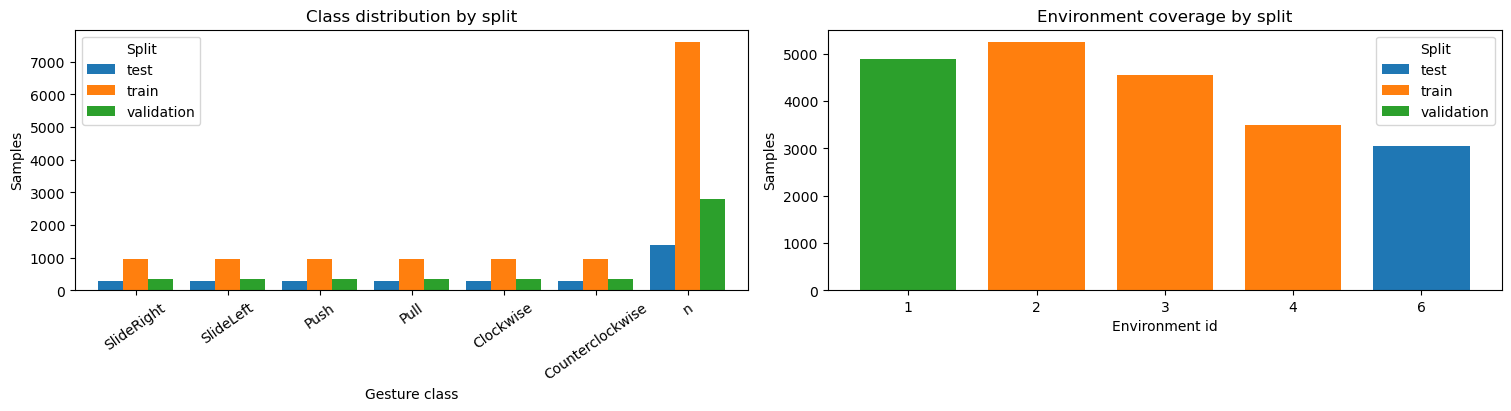

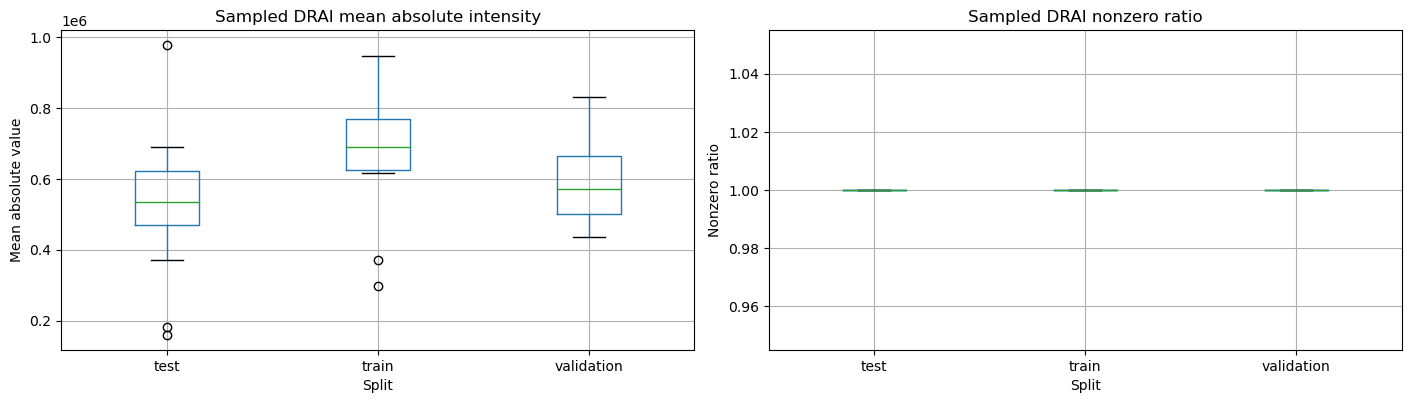

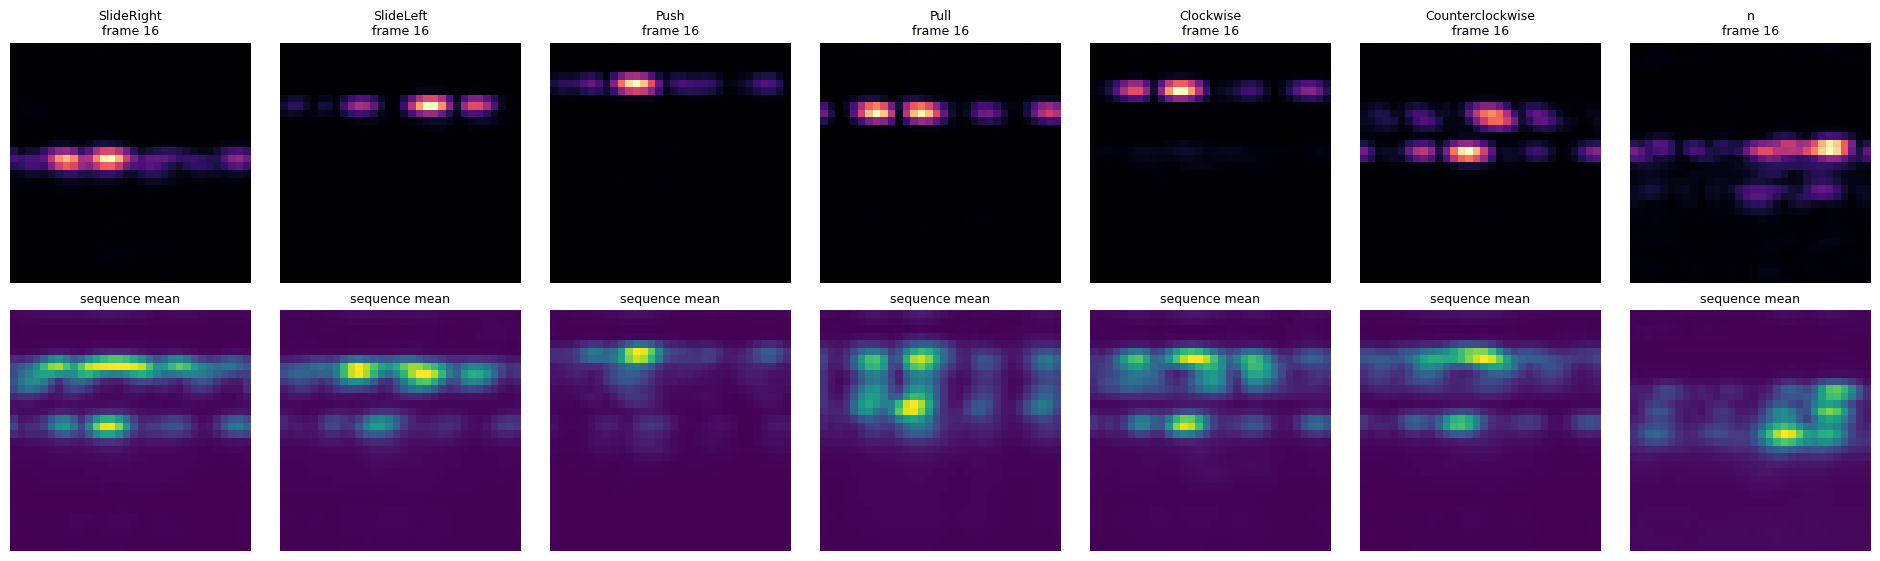

In [18]:
# Data visualization module: split balance and representative DRAI samples.
import matplotlib.pyplot as plt

class_balance_plot_df = CLASS_BALANCE_DF.pivot(index="class", columns="split", values="count").reindex(ACTION_NAMES)
environment_plot_df = ENVIRONMENT_SPLIT_DF.pivot_table(
    index="environment_id",
    columns="split",
    values="count",
    aggfunc="sum",
    fill_value=0,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)
class_balance_plot_df.plot(kind="bar", ax=axes[0], width=0.82)
axes[0].set_title("Class distribution by split")
axes[0].set_xlabel("Gesture class")
axes[0].set_ylabel("Samples")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="Split")

environment_plot_df.plot(kind="bar", stacked=True, ax=axes[1], width=0.75)
axes[1].set_title("Environment coverage by split")
axes[1].set_xlabel("Environment id")
axes[1].set_ylabel("Samples")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Split")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
DRAI_SAMPLE_STATS_DF.boxplot(column="mean_abs", by="split", ax=axes[0])
axes[0].set_title("Sampled DRAI mean absolute intensity")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Mean absolute value")

DRAI_SAMPLE_STATS_DF.boxplot(column="nonzero_ratio", by="split", ax=axes[1])
axes[1].set_title("Sampled DRAI nonzero ratio")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Nonzero ratio")
fig.suptitle("")
plt.show()

# Show one deterministic training example per class: center frame and sequence average.
train_label_names = label_encoder.inverse_transform(train_labels)
representative_files = []
for class_name in ACTION_NAMES:
    candidates = [file_name for file_name, label_name in zip(train_files, train_label_names) if label_name == class_name]
    if candidates:
        representative_files.append((class_name, candidates[0]))

if representative_files:
    fig, axes = plt.subplots(2, len(representative_files), figsize=(2.7 * len(representative_files), 5.5), constrained_layout=True)
    if len(representative_files) == 1:
        axes = np.array(axes).reshape(2, 1)
    for column_index, (class_name, file_name) in enumerate(representative_files):
        frames = np.load(CONFIG.data_path / file_name).astype(np.float32)
        center_index = min(len(frames) - 1, CONFIG.seq_len // 2)
        center_frame = frames[center_index]
        mean_frame = frames[: CONFIG.seq_len].mean(axis=0)

        axes[0, column_index].imshow(center_frame, cmap="magma")
        axes[0, column_index].set_title(f"{class_name}\nframe {center_index}", fontsize=9)
        axes[0, column_index].axis("off")

        axes[1, column_index].imshow(mean_frame, cmap="viridis")
        axes[1, column_index].set_title("sequence mean", fontsize=9)
        axes[1, column_index].axis("off")
    plt.show()


### 4.1 Additional Data Analysis Visualizations

These plots add a compact view of split size, class share, sequence length, and sampled DRAI intensity by class.

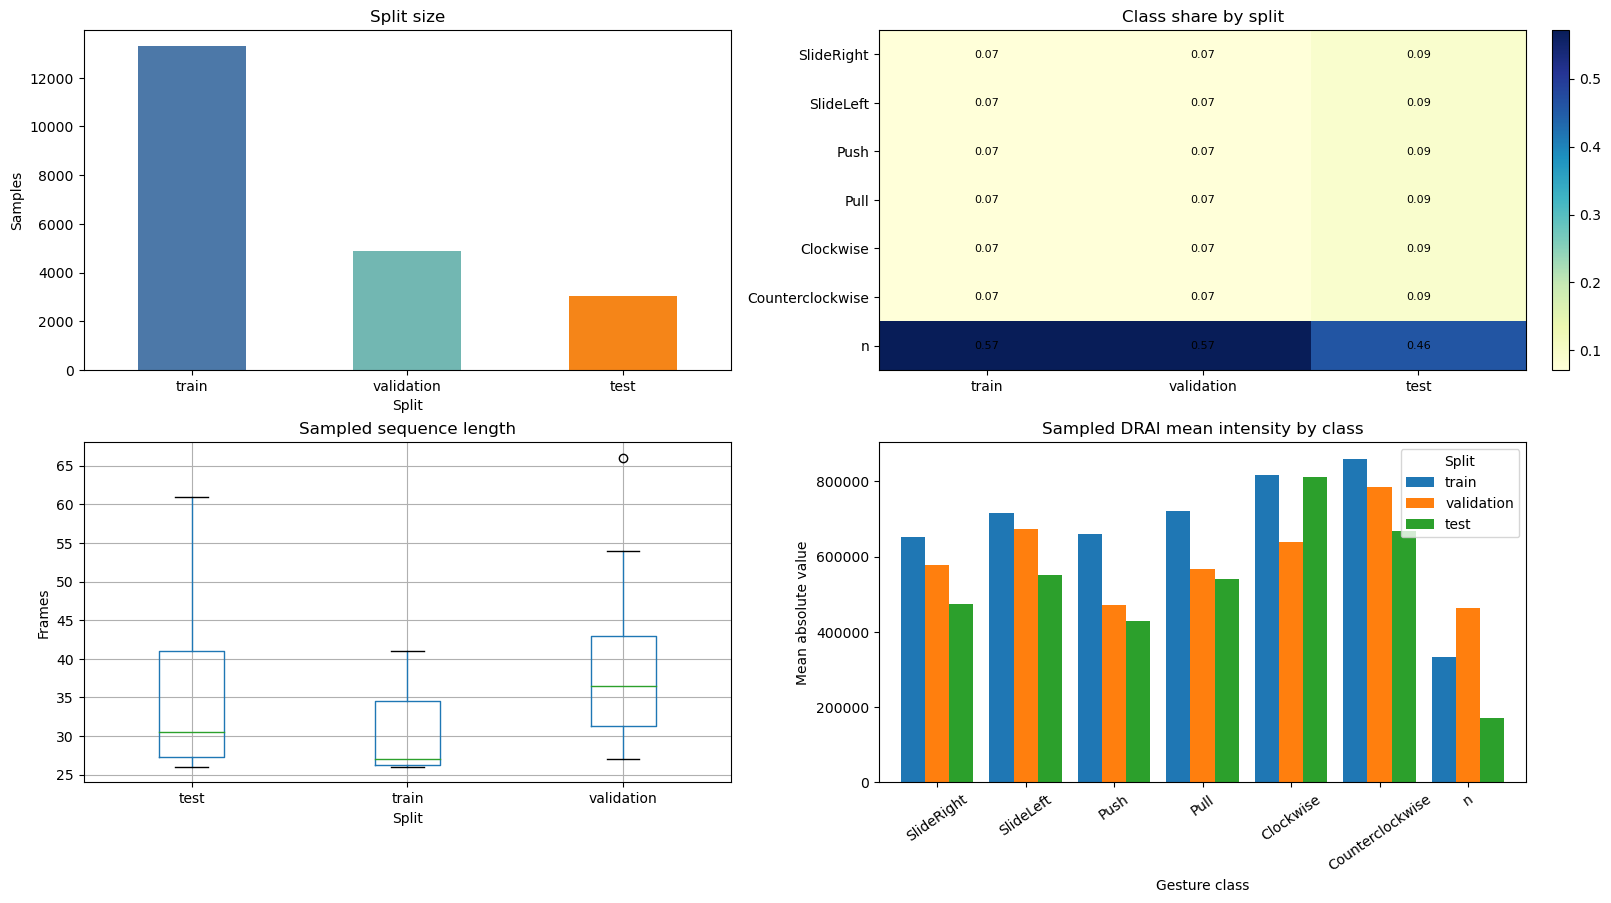

In [19]:
# Additional data analysis visualizations.
split_order = ["train", "validation", "test"]
class_order = list(ACTION_NAMES)

split_size_series = SPLIT_SUMMARY_DF.set_index("split").reindex(split_order)["samples"]
class_share_df = CLASS_BALANCE_DF.copy()
class_share_df["share"] = class_share_df["count"] / class_share_df.groupby("split")["count"].transform("sum")
class_share_plot_df = (
    class_share_df.pivot(index="class", columns="split", values="share")
    .reindex(class_order)
    .reindex(columns=split_order)
)
mean_abs_by_class_df = (
    DRAI_SAMPLE_STATS_DF.groupby(["class", "split"])["mean_abs"]
    .mean()
    .unstack("split")
    .reindex(class_order)
    .reindex(columns=split_order)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 9), constrained_layout=True)

split_size_series.plot(kind="bar", ax=axes[0, 0], color=["#4C78A8", "#72B7B2", "#F58518"])
axes[0, 0].set_title("Split size")
axes[0, 0].set_xlabel("Split")
axes[0, 0].set_ylabel("Samples")
axes[0, 0].tick_params(axis="x", rotation=0)

class_share_values = class_share_plot_df.to_numpy(dtype=float)
share_image = axes[0, 1].imshow(class_share_values, aspect="auto", cmap="YlGnBu")
axes[0, 1].set_title("Class share by split")
axes[0, 1].set_xticks(range(len(class_share_plot_df.columns)))
axes[0, 1].set_xticklabels(class_share_plot_df.columns)
axes[0, 1].set_yticks(range(len(class_share_plot_df.index)))
axes[0, 1].set_yticklabels(class_share_plot_df.index)
for row_index in range(class_share_values.shape[0]):
    for col_index in range(class_share_values.shape[1]):
        axes[0, 1].text(col_index, row_index, f"{class_share_values[row_index, col_index]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(share_image, ax=axes[0, 1], fraction=0.046, pad=0.04)

DRAI_SAMPLE_STATS_DF.boxplot(column="frames", by="split", ax=axes[1, 0])
axes[1, 0].set_title("Sampled sequence length")
axes[1, 0].set_xlabel("Split")
axes[1, 0].set_ylabel("Frames")

mean_abs_by_class_df.plot(kind="bar", ax=axes[1, 1], width=0.82)
axes[1, 1].set_title("Sampled DRAI mean intensity by class")
axes[1, 1].set_xlabel("Gesture class")
axes[1, 1].set_ylabel("Mean absolute value")
axes[1, 1].tick_params(axis="x", rotation=35)
axes[1, 1].legend(title="Split")
fig.suptitle("")
plt.show()


### 4.2 Bias Audit Visualizations

These plots summarize the bias audit by risk level, label-distribution deviation, and sampled signal drift from train.

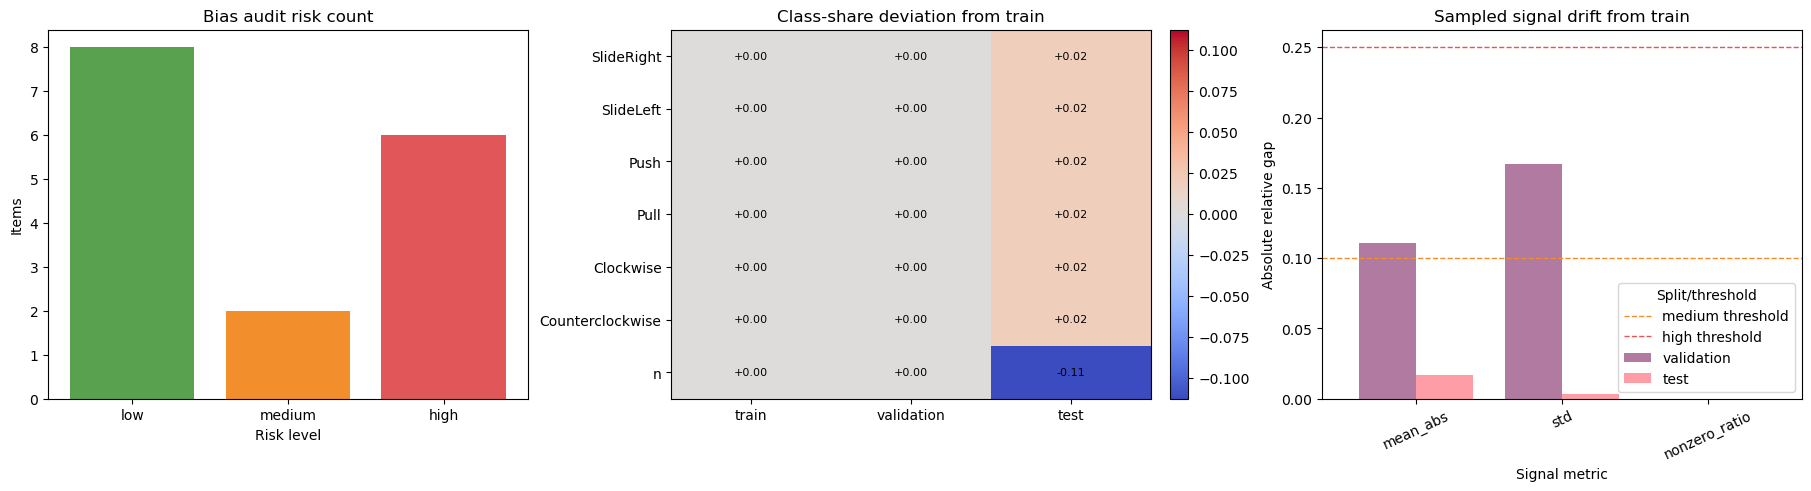

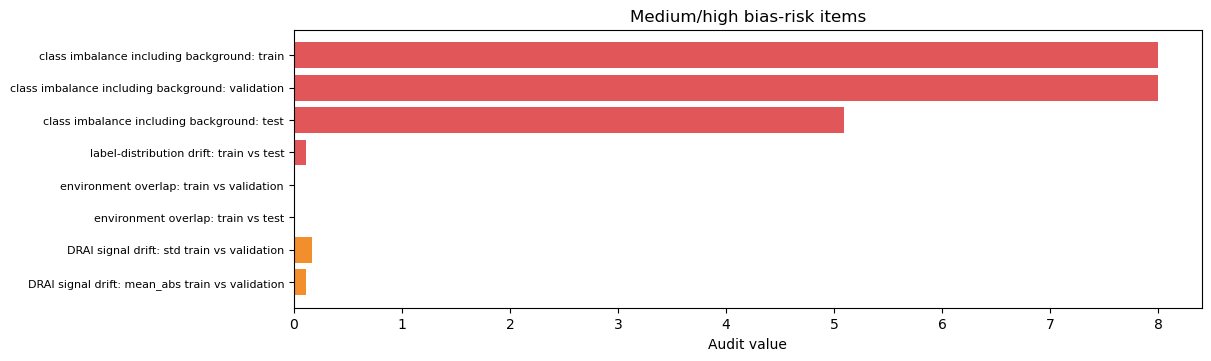

In [20]:
# Bias audit visualizations.
risk_order = ["low", "medium", "high"]
risk_colors = {"low": "#59A14F", "medium": "#F28E2B", "high": "#E15759"}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

risk_counts = BIAS_AUDIT_SUMMARY_DF["risk"].value_counts().reindex(risk_order, fill_value=0)
axes[0].bar(risk_counts.index, risk_counts.values, color=[risk_colors[level] for level in risk_counts.index])
axes[0].set_title("Bias audit risk count")
axes[0].set_xlabel("Risk level")
axes[0].set_ylabel("Items")

class_deviation_df = (
    BIAS_CLASS_DISTRIBUTION_DF.pivot(index="class", columns="split", values="deviation_from_train")
    .reindex(class_order)
    .reindex(columns=split_order)
)
class_deviation_values = class_deviation_df.to_numpy(dtype=float)
deviation_limit = max(0.001, float(np.nanmax(np.abs(class_deviation_values))))
deviation_image = axes[1].imshow(class_deviation_values, aspect="auto", cmap="coolwarm", vmin=-deviation_limit, vmax=deviation_limit)
axes[1].set_title("Class-share deviation from train")
axes[1].set_xticks(range(len(class_deviation_df.columns)))
axes[1].set_xticklabels(class_deviation_df.columns)
axes[1].set_yticks(range(len(class_deviation_df.index)))
axes[1].set_yticklabels(class_deviation_df.index)
for row_index in range(class_deviation_values.shape[0]):
    for col_index in range(class_deviation_values.shape[1]):
        axes[1].text(col_index, row_index, f"{class_deviation_values[row_index, col_index]:+.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(deviation_image, ax=axes[1], fraction=0.046, pad=0.04)

signal_drift_plot_df = BIAS_SIGNAL_DRIFT_DF.loc[BIAS_SIGNAL_DRIFT_DF["split"] != "train"].copy()
signal_drift_plot_df["abs_gap"] = signal_drift_plot_df["relative_gap_from_train"].abs()
signal_drift_pivot_df = (
    signal_drift_plot_df.pivot(index="metric", columns="split", values="abs_gap")
    .reindex(["mean_abs", "std", "nonzero_ratio"])
    .reindex(columns=["validation", "test"])
)
signal_drift_pivot_df.plot(kind="bar", ax=axes[2], width=0.78, color=["#B07AA1", "#FF9DA7"])
axes[2].axhline(0.10, color="#F28E2B", linestyle="--", linewidth=1, label="medium threshold")
axes[2].axhline(0.25, color="#E15759", linestyle="--", linewidth=1, label="high threshold")
axes[2].set_title("Sampled signal drift from train")
axes[2].set_xlabel("Signal metric")
axes[2].set_ylabel("Absolute relative gap")
axes[2].tick_params(axis="x", rotation=25)
axes[2].legend(title="Split/threshold")
plt.show()

non_low_risk_df = BIAS_AUDIT_SUMMARY_DF.loc[BIAS_AUDIT_SUMMARY_DF["risk"].isin(["medium", "high"])].copy()
if not non_low_risk_df.empty:
    non_low_risk_df = non_low_risk_df.sort_values(["risk", "value"], ascending=[True, False])
    fig, ax = plt.subplots(figsize=(12, max(3.5, 0.42 * len(non_low_risk_df))), constrained_layout=True)
    y_positions = np.arange(len(non_low_risk_df))
    ax.barh(
        y_positions,
        non_low_risk_df["value"].astype(float),
        color=[risk_colors[level] for level in non_low_risk_df["risk"]],
    )
    ax.set_yticks(y_positions)
    ax.set_yticklabels(non_low_risk_df["audit_item"], fontsize=8)
    ax.invert_yaxis()
    ax.set_title("Medium/high bias-risk items")
    ax.set_xlabel("Audit value")
    plt.show()


## 5. Model Registry

This table checks each selected model, its display name, parameter count, and batch size before training.

In [21]:
# Build each selected model once to count trainable parameters.
MODEL_REGISTRY_DF = model_registry_frame(
    CONFIG.models,
    MODEL_DISPLAY_NAMES,
    lambda model_name: build_model(model_name, CONFIG),
)
display(MODEL_REGISTRY_DF)


,model,display_name,params_m,batch_size,available,registry_error
0,crnn,CRNN Baseline,0.346,64,True,
1,cnn_transformer,CNN + Transformer,0.500,32,True,
2,trans_cnn_1d,TRANS-CNN-1D,0.435,32,True,
3,lpvt_full,LPVT-Full,5.483,6,True,
4,mobilevit_full,MobileViT (Project Full),3.655,6,True,
5,paper_mobilevit_teacher,MobileViT (Paper Teacher),0.096,24,True,
6,paper_mobilevit_student,MobileViT (Paper Student + KD),0.024,32,True,
7,external_mobilevit_frozen,MobileViT (External Frozen),5.117,2,True,
8,timesformer_full,TimeSformer-Full,4.459,2,True,


## 6. Run Experiment

`run_experiment()` performs validation checks, training, validation, testing, best-state tracking, progress recording, and failure reporting.

In [22]:
# Run the selected smoke or full experiment.
RUN_OUTPUT = run_experiment(
    CONFIG,
    train_files,
    train_labels,
    val_files,
    val_labels,
    test_files,
    test_labels,
)

# Expose named outputs for the reporting cells below.
SMOKE_DF = RUN_OUTPUT.smoke_df
RESULTS_DF = RUN_OUTPUT.results_df
HISTORIES = RUN_OUTPUT.histories
TEST_DETAILS = RUN_OUTPUT.test_details
FAILED_MODELS = RUN_OUTPUT.failed_models
EXPERIMENT_TOTAL_SECONDS = RUN_OUTPUT.total_seconds
RUN_PROGRESS_DF = RUN_OUTPUT.progress_df
RUN_PROGRESS_SUMMARY_DF = RUN_OUTPUT.progress_summary_df
RUN_PROGRESS_TAIL_DF = RUN_OUTPUT.progress_tail_df

# Optional diagnostic tables can be displayed after the run.
# if not SMOKE_DF.empty:
#     display(SMOKE_DF)
# if FAILED_MODELS:
#     display(pd.DataFrame(FAILED_MODELS))
# if not RUN_PROGRESS_SUMMARY_DF.empty:
#     display(RUN_PROGRESS_SUMMARY_DF)
# if not RUN_PROGRESS_TAIL_DF.empty:
#     display(RUN_PROGRESS_TAIL_DF)

Training/evaluation run on mps: 9 selected model(s)

=== [1/9] Running CRNN Baseline on mps ===
[cache] using saved result for CRNN Baseline: /Users/blue/Desktop/Practicum/code/experiment1/cache/full/crnn/cf2ff602f54617aa
[done] model 1/9: CRNN Baseline | test_bal_acc=0.9062

=== [2/9] Running CNN + Transformer on mps ===
[cache] using saved result for CNN + Transformer: /Users/blue/Desktop/Practicum/code/experiment1/cache/full/cnn_transformer/127dea46d259e057
[done] model 2/9: CNN + Transformer | test_bal_acc=0.9147

=== [3/9] Running TRANS-CNN-1D on mps ===
[cache] using saved result for TRANS-CNN-1D: /Users/blue/Desktop/Practicum/code/experiment1/cache/full/trans_cnn_1d/4e9420c82a811b17
[done] model 3/9: TRANS-CNN-1D | test_bal_acc=0.8918

=== [4/9] Running LPVT-Full on mps ===
[cache] using saved result for LPVT-Full: /Users/blue/Desktop/Practicum/code/experiment1/cache/full/lpvt_full/33d5f36a16f28162
[done] model 4/9: LPVT-Full | test_bal_acc=0.9466

=== [5/9] Running MobileViT (P

## 7. Parameter Selection Evidence from Epoch Curves



,model,model_key,epochs,batch_size,learning_rate,weight_decay,label_smoothing,grad_clip,warmup_epochs,use_cosine,...,final_val_balanced_acc,final_val_macro_f1,best_to_final_bal_acc_delta,final_train_val_bal_acc_gap,params_m,train_seconds,test_acc,test_bal_acc,test_macro_f1,best_val_to_test_bal_acc_gap
0,CRNN Baseline,crnn,20,64,0.00010,0.0001,0.00,<NA>,0,False,...,0.9758,0.9690,0.0000,0.0180,0.346,347.1,0.9292,0.9062,0.9082,0.0696
1,CNN + Transformer,cnn_transformer,40,32,0.00040,0.0300,0.03,1.0,5,True,...,0.9899,0.9902,0.0008,0.0079,0.500,1200.9,0.9433,0.9147,0.9257,0.0760
2,TRANS-CNN-1D,trans_cnn_1d,40,32,0.00010,0.0001,0.03,0.25,5,True,...,0.9827,0.9824,0.0005,0.0168,0.435,1937.4,0.9246,0.8918,0.9032,0.0914
3,LPVT-Full,lpvt_full,30,6,0.00020,0.0500,0.05,1.0,6,True,...,0.9916,0.9925,0.0000,0.0056,5.483,18503.7,0.9600,0.9466,0.9550,0.0450
4,MobileViT (Project Full),mobilevit_full,30,6,0.00020,0.0500,0.05,1.0,6,True,...,0.9965,0.9969,0.0001,0.0012,3.655,18684.2,0.9479,0.9266,0.9367,0.0700
5,MobileViT (Paper Teacher),paper_mobilevit_teacher,40,24,0.00030,0.0300,0.03,1.0,5,True,...,0.9710,0.9705,0.0060,0.0226,0.096,4338.1,0.9138,0.8863,0.8886,0.0907
6,MobileViT (Paper Student + KD),paper_mobilevit_student,40,32,0.00030,0.0200,0.00,1.0,5,True,...,0.9311,0.9263,0.0036,0.0073,0.024,3402.9,0.8833,0.8418,0.8485,0.0929
7,MobileViT (External Frozen),external_mobilevit_frozen,20,2,0.00010,0.0001,0.03,1.0,0,False,...,0.1429,0.1039,0.3302,0.0913,5.117,58291.9,0.6118,0.4509,0.3917,0.0221
8,TimeSformer-Full,timesformer_full,30,2,0.00015,0.0500,0.05,1.0,6,True,...,0.5321,0.5987,0.0008,0.2187,4.459,20214.3,0.6108,0.4009,0.4626,0.1320


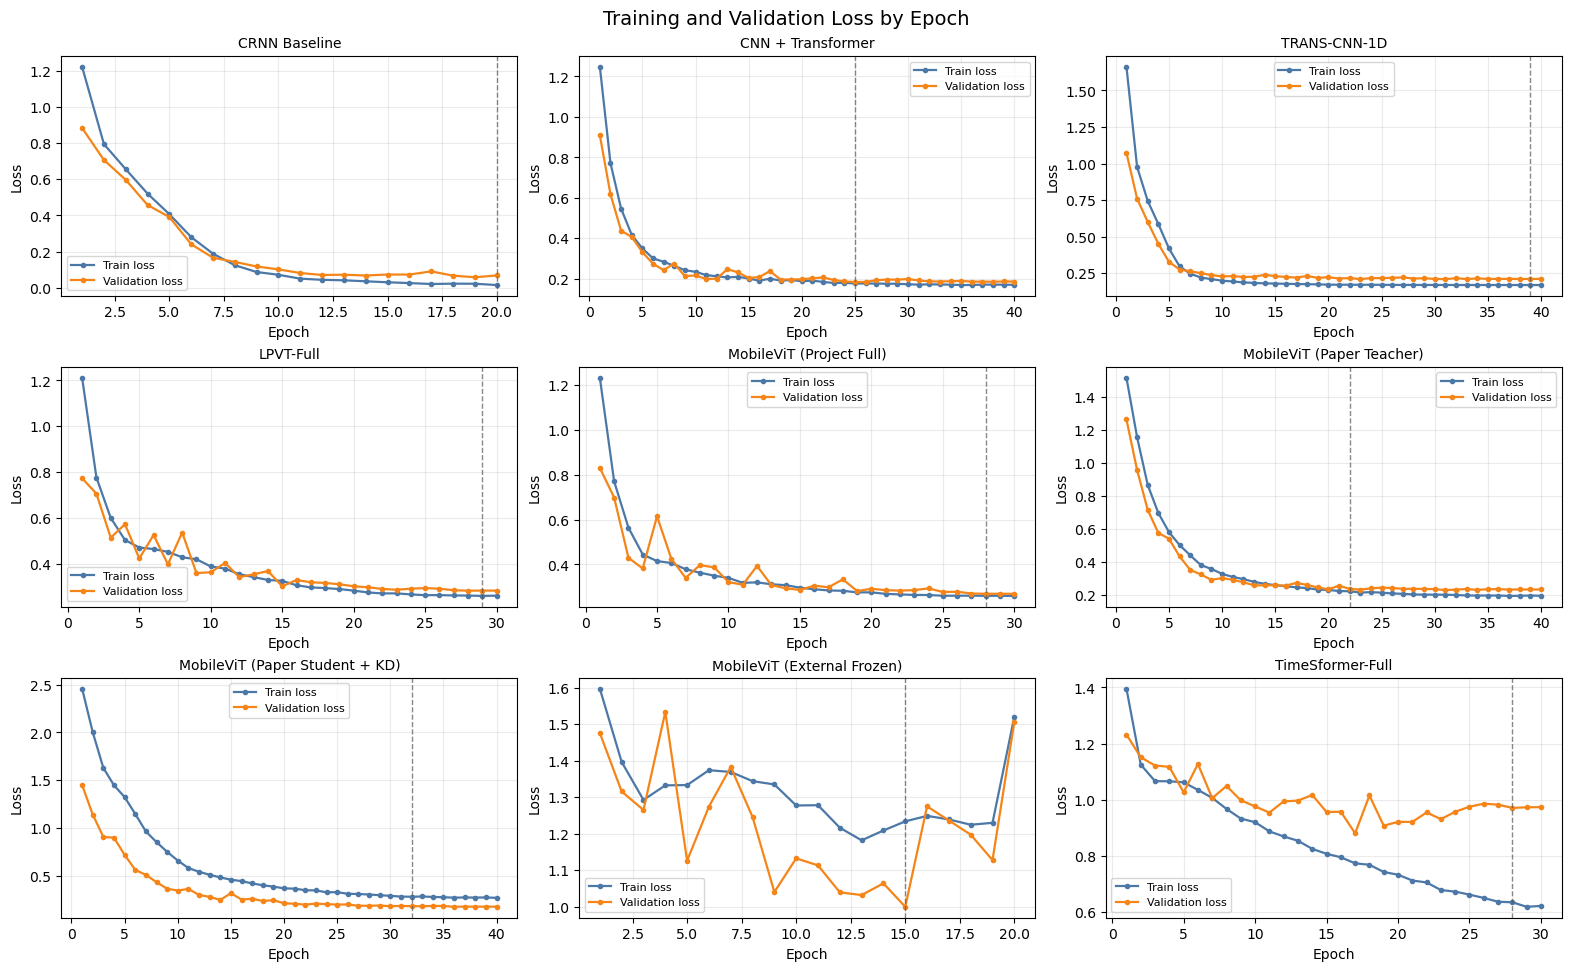

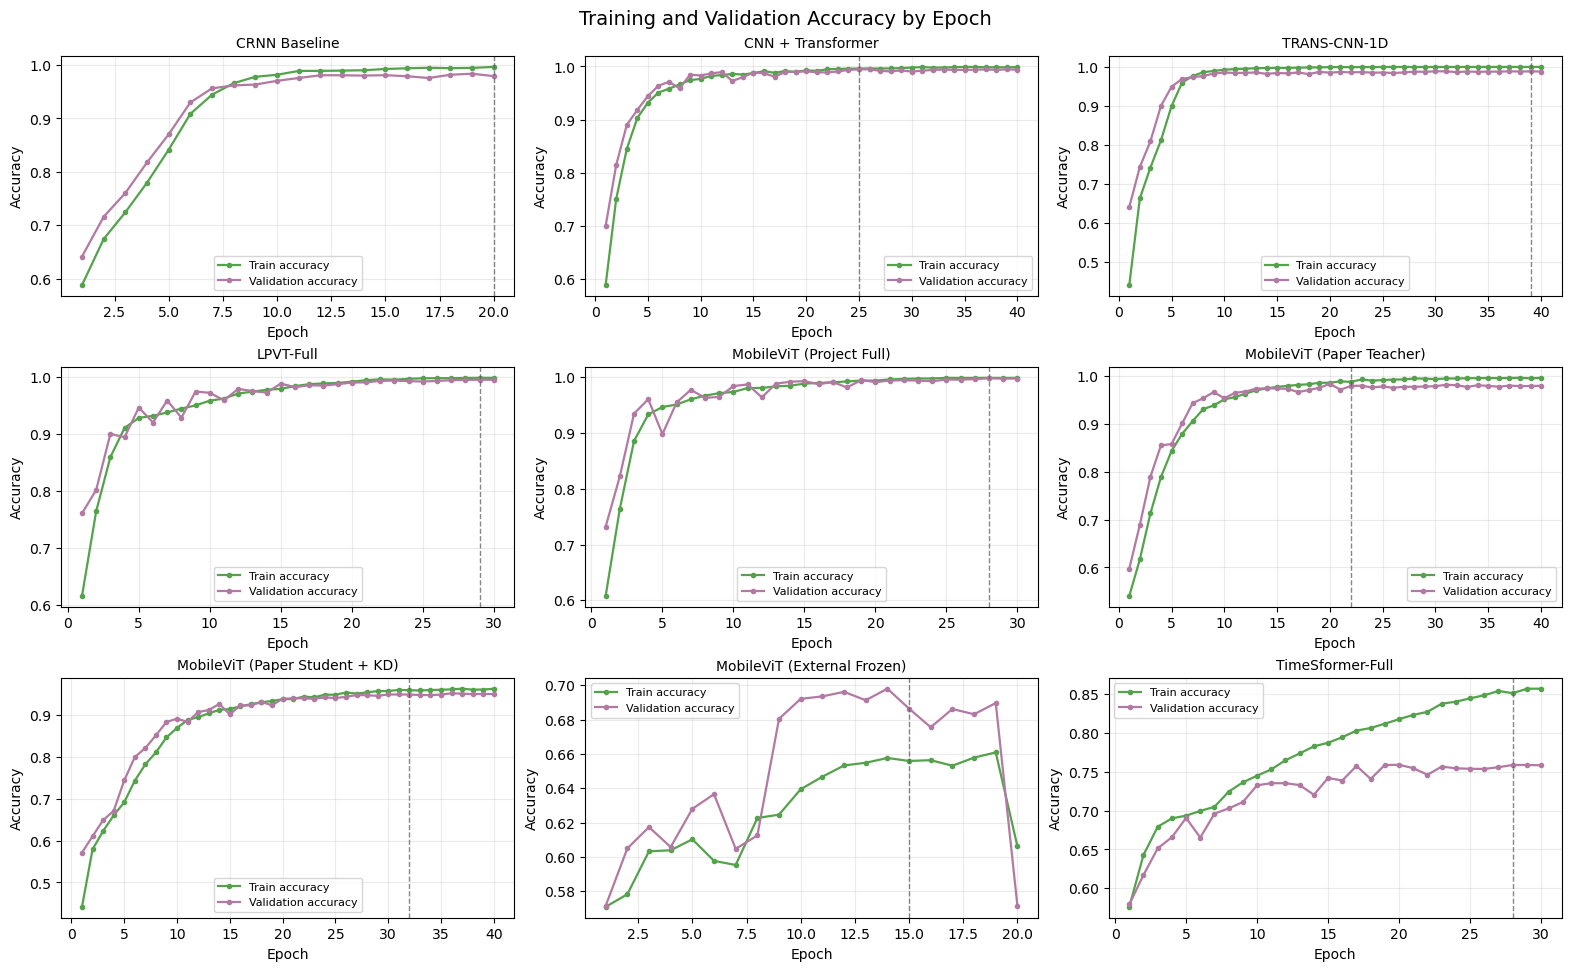

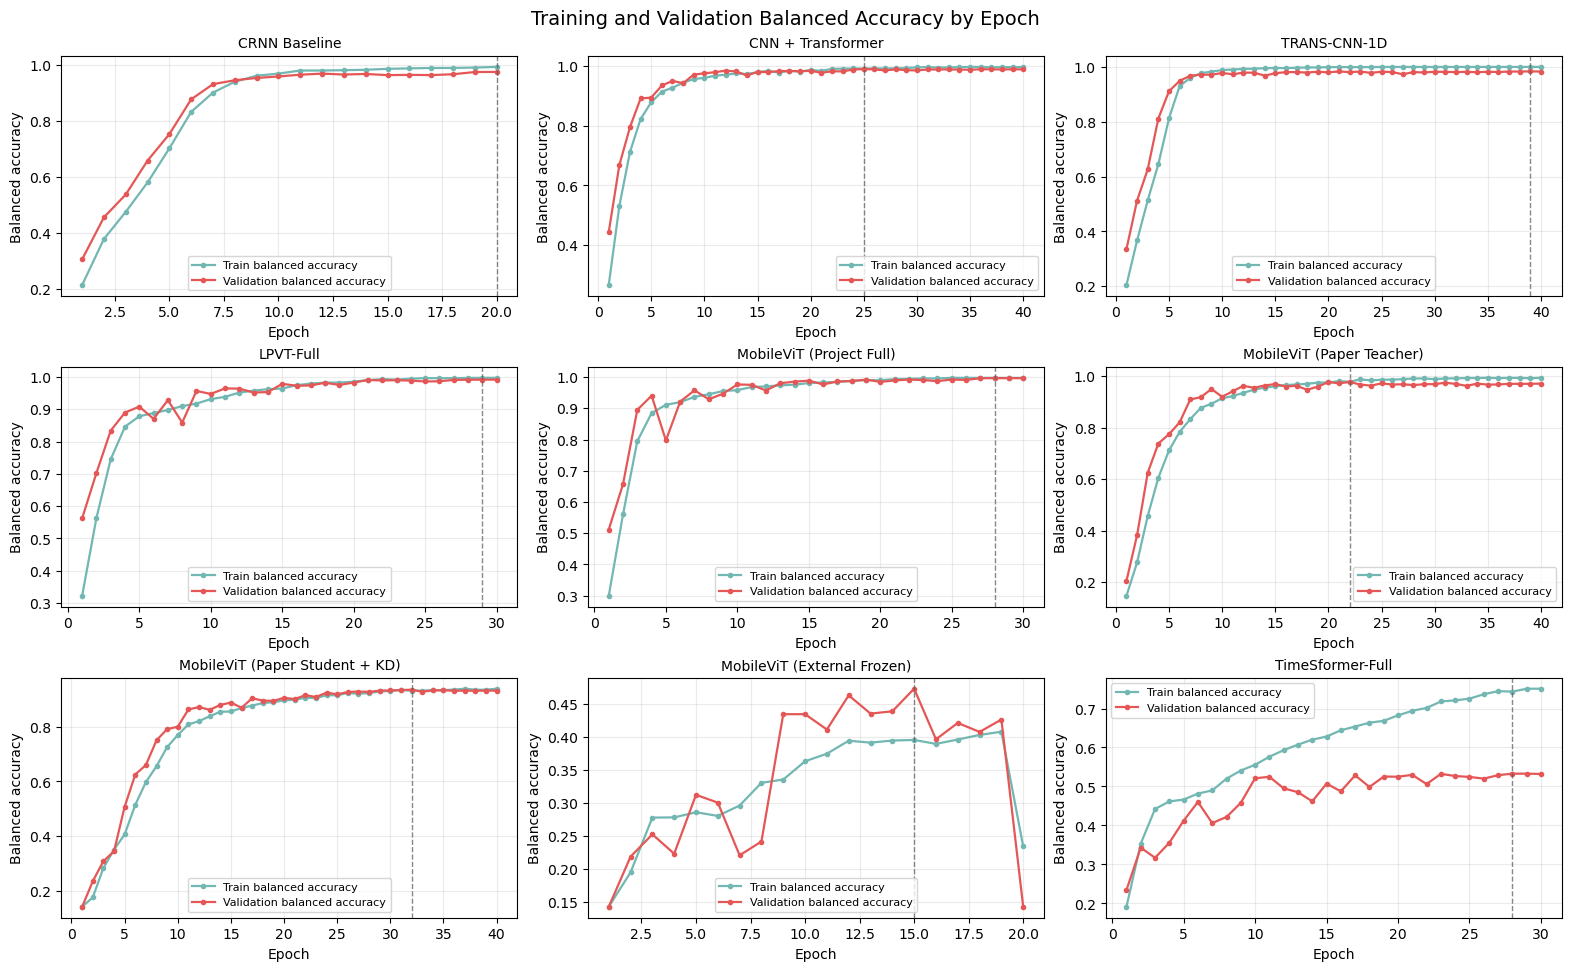

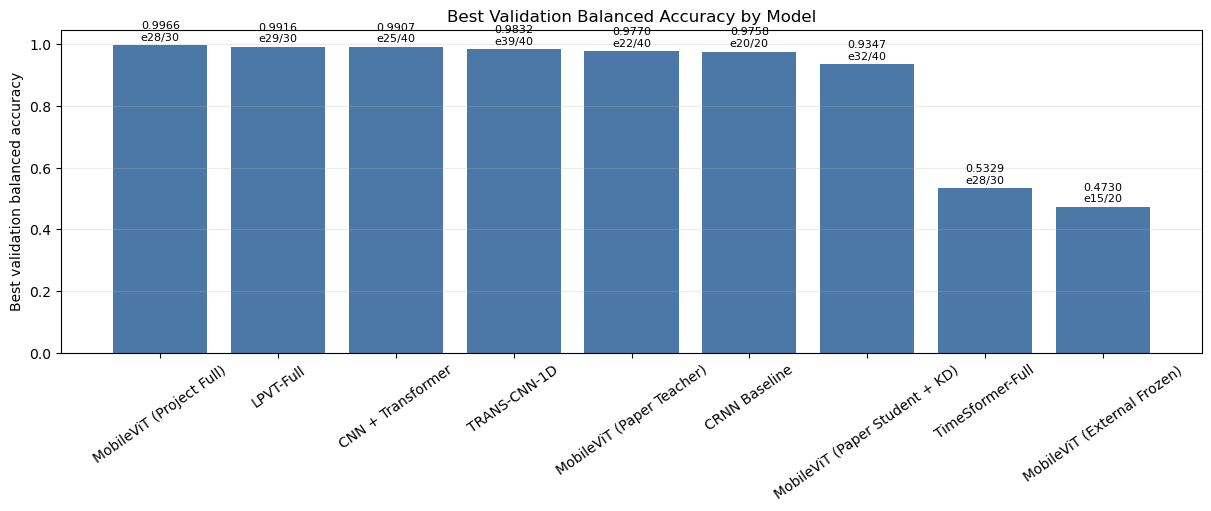

In [23]:
# Numeric parameter-selection evidence based on histories returned by the current run.
# This cell is read-only with respect to training configuration, cache files, and data files.
import math
import matplotlib.pyplot as plt

from experiment_config import model_batch_size, model_training_profile


EPOCH_DIAGNOSTIC_MODELS = list(CONFIG.models)


def collect_epoch_history(histories, model_order):
    rows = []
    for model_name in model_order:
        history_df = histories.get(model_name)
        if history_df is None or history_df.empty:
            continue
        frame = history_df.copy()
        frame["model"] = model_name
        frame["display_name"] = MODEL_DISPLAY_NAMES.get(model_name, model_name)
        rows.append(frame)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def maybe_round(value, digits=4):
    if pd.isna(value):
        return pd.NA
    return round(float(value), digits)


EPOCH_HISTORY_DF = collect_epoch_history(HISTORIES, EPOCH_DIAGNOSTIC_MODELS)

if EPOCH_HISTORY_DF.empty:
    EPOCH_CURVE_SUMMARY_DF = pd.DataFrame()
    print("No per-epoch history is available. Run training or load full cached histories before plotting epoch curves.")
else:
    result_lookup = {}
    if "RESULTS_DF" in globals() and RESULTS_DF is not None and not RESULTS_DF.empty:
        result_lookup = RESULTS_DF.set_index("model").to_dict("index")

    summary_rows = []
    for model_name in EPOCH_DIAGNOSTIC_MODELS:
        frame = EPOCH_HISTORY_DF.loc[EPOCH_HISTORY_DF["model"] == model_name].copy()
        if frame.empty:
            continue
        frame = frame.sort_values("epoch").reset_index(drop=True)
        profile = model_training_profile(model_name, CONFIG)
        batch_size = model_batch_size(model_name)
        best_acc = frame.loc[frame["val_acc"].astype(float).idxmax()]
        best_balanced = frame.loc[frame["val_balanced_acc"].astype(float).idxmax()]
        best_macro_f1 = frame.loc[frame["val_macro_f1"].astype(float).idxmax()]
        final = frame.iloc[-1]
        result = result_lookup.get(model_name, {})
        test_bal_acc = result.get("test_bal_acc", pd.NA)
        val_test_bal_gap = pd.NA if pd.isna(test_bal_acc) else float(best_balanced["val_balanced_acc"]) - float(test_bal_acc)
        summary_rows.append(
            {
                "model": MODEL_DISPLAY_NAMES.get(model_name, model_name),
                "model_key": model_name,
                "epochs": int(profile["epochs"]),
                "batch_size": int(batch_size),
                "learning_rate": float(profile["learning_rate"]),
                "weight_decay": float(profile["weight_decay"]),
                "label_smoothing": float(profile["label_smoothing"]),
                "grad_clip": pd.NA if profile["clip_grad_norm"] is None else float(profile["clip_grad_norm"]),
                "warmup_epochs": int(profile["warmup_epochs"]),
                "use_cosine": bool(profile["use_cosine"]),
                "augmentation": bool(profile["augmentation"]),
                "motion_input": bool(profile["motion_input"]),
                "best_val_acc_epoch": int(best_acc["epoch"]),
                "best_val_acc": maybe_round(best_acc["val_acc"]),
                "best_val_balanced_acc_epoch": int(best_balanced["epoch"]),
                "best_val_balanced_acc": maybe_round(best_balanced["val_balanced_acc"]),
                "best_val_macro_f1_epoch": int(best_macro_f1["epoch"]),
                "best_val_macro_f1": maybe_round(best_macro_f1["val_macro_f1"]),
                "final_val_acc": maybe_round(final["val_acc"]),
                "final_val_balanced_acc": maybe_round(final["val_balanced_acc"]),
                "final_val_macro_f1": maybe_round(final["val_macro_f1"]),
                "best_to_final_bal_acc_delta": maybe_round(float(best_balanced["val_balanced_acc"]) - float(final["val_balanced_acc"])),
                "final_train_val_bal_acc_gap": maybe_round(float(final["train_balanced_acc"]) - float(final["val_balanced_acc"])),
                "params_m": maybe_round(result.get("params_m", pd.NA), digits=3),
                "train_seconds": maybe_round(result.get("train_seconds", pd.NA), digits=1),
                "test_acc": maybe_round(result.get("test_acc", pd.NA)),
                "test_bal_acc": maybe_round(test_bal_acc),
                "test_macro_f1": maybe_round(result.get("test_macro_f1", pd.NA)),
                "best_val_to_test_bal_acc_gap": maybe_round(val_test_bal_gap),
            }
        )

    EPOCH_CURVE_SUMMARY_DF = pd.DataFrame(summary_rows)
    display(EPOCH_CURVE_SUMMARY_DF)

    model_order = [model for model in EPOCH_DIAGNOSTIC_MODELS if model in set(EPOCH_HISTORY_DF["model"])]
    n_models = len(model_order)
    n_cols = 3
    n_rows = math.ceil(n_models / n_cols)

    def plot_epoch_grid(metric_pairs, title, ylabel):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.2 * n_rows), constrained_layout=True)
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
        best_epoch_lookup = dict(
            zip(EPOCH_CURVE_SUMMARY_DF["model"], EPOCH_CURVE_SUMMARY_DF["best_val_balanced_acc_epoch"])
        )
        for ax, model_name in zip(axes, model_order):
            frame = EPOCH_HISTORY_DF.loc[EPOCH_HISTORY_DF["model"] == model_name].sort_values("epoch")
            display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)
            for column, label, color in metric_pairs:
                ax.plot(frame["epoch"], frame[column], marker="o", markersize=3, linewidth=1.6, label=label, color=color)
            best_epoch = best_epoch_lookup.get(display_name)
            if best_epoch is not None:
                ax.axvline(best_epoch, color="#555555", linestyle="--", linewidth=1.0, alpha=0.7)
            ax.set_title(display_name, fontsize=10)
            ax.set_xlabel("Epoch")
            ax.set_ylabel(ylabel)
            ax.grid(alpha=0.25)
            ax.legend(fontsize=8)
        for ax in axes[n_models:]:
            ax.axis("off")
        fig.suptitle(title, fontsize=14)
        plt.show()

    def plot_best_validation_balanced_accuracy(summary_df):
        plot_df = summary_df.sort_values("best_val_balanced_acc", ascending=False).reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
        bars = ax.bar(plot_df["model"], plot_df["best_val_balanced_acc"], color="#4C78A8")
        ax.set_title("Best Validation Balanced Accuracy by Model")
        ax.set_ylabel("Best validation balanced accuracy")
        ax.set_ylim(0, max(1.0, float(plot_df["best_val_balanced_acc"].max()) + 0.05))
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="x", labelrotation=35)
        for bar, (_, row) in zip(bars, plot_df.iterrows()):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{row['best_val_balanced_acc']:.4f}" + chr(10) + f"e{int(row['best_val_balanced_acc_epoch'])}/{int(row['epochs'])}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
        plt.show()

    plot_epoch_grid(
        [("train_loss", "Train loss", "#4C78A8"), ("val_loss", "Validation loss", "#F58518")],
        "Training and Validation Loss by Epoch",
        "Loss",
    )
    plot_epoch_grid(
        [("train_acc", "Train accuracy", "#54A24B"), ("val_acc", "Validation accuracy", "#B279A2")],
        "Training and Validation Accuracy by Epoch",
        "Accuracy",
    )
    plot_epoch_grid(
        [("train_balanced_acc", "Train balanced accuracy", "#72B7B2"), ("val_balanced_acc", "Validation balanced accuracy", "#E45756")],
        "Training and Validation Balanced Accuracy by Epoch",
        "Balanced accuracy",
    )
    plot_best_validation_balanced_accuracy(EPOCH_CURVE_SUMMARY_DF)


## 8. Result Tables



In [24]:
# Adapter keeps reporting independent from the exact DataLoader signature.
def notebook_loader(files, labels, model_name, shuffle):
    return make_loader(CONFIG.data_path, files, labels, CONFIG.seq_len, model_name, shuffle)

# Build and display all result tables in a stable order.
REPORT_TABLES = build_report_tables(
    CONFIG,
    label_encoder,
    train_files,
    train_labels,
    val_files,
    val_labels,
    test_files,
    test_labels,
    MODEL_REGISTRY_DF,
    RESULTS_DF,
    FAILED_MODELS,
    EXPERIMENT_TOTAL_SECONDS,
    notebook_loader,
    progress_summary_df=RUN_PROGRESS_SUMMARY_DF,
    progress_tail_df=RUN_PROGRESS_TAIL_DF,
)
display_report_tables(REPORT_TABLES)

# Expose named tables for subsequent analysis and visualisation.
DATASET_SUMMARY_DF = REPORT_TABLES.get("dataset_summary", pd.DataFrame())
CLASS_DISTRIBUTION_DF = REPORT_TABLES.get("class_distribution", pd.DataFrame())
MODEL_HYPERPARAMETER_DF = REPORT_TABLES.get("model_hyperparameters", pd.DataFrame())
ACCURACY_COMPARISON_DF = REPORT_TABLES.get("accuracy_comparison", pd.DataFrame())
RUNTIME_DF = REPORT_TABLES.get("runtime_detail", pd.DataFrame())
RUNTIME_TOTAL_DF = REPORT_TABLES.get("runtime_total", pd.DataFrame())
RUNTIME_PER_MODEL_SUMMARY_DF = REPORT_TABLES.get("runtime_per_model", pd.DataFrame())
RUNTIME_GROUP_DF = REPORT_TABLES.get("runtime_by_family", pd.DataFrame())
TRANSFORMER_ADVANTAGE_DF = REPORT_TABLES.get("transformer_advantage", pd.DataFrame())


Dataset summary


,split,environment_ids,samples,n_samples,gesture_samples,min_gesture_class,max_gesture_class,n_to_min_gesture_ratio,configured_limit
0,train,"e2,e3,e4",13300,7600,5700,950,950,8.00,full
1,validation,e1,4900,2800,2100,350,350,8.00,full
2,test,e6,3050,1400,1650,275,275,5.09,full


Class distribution by split


,class_label,train,validation,test
0,Clockwise,950,350,275
1,Counterclockwise,950,350,275
2,Pull,950,350,275
3,Push,950,350,275
4,SlideLeft,950,350,275
5,SlideRight,950,350,275
6,n,7600,2800,1400


Model parameters, architecture, and training hyperparameters


...

,model,model_key,family,params_M,batch_size,epochs,train_batches_per_epoch,val_batches_per_epoch,test_batches_final,epoch_train_val_batches,...,seconds_per_train_val_batch,samples_per_second_train_split,seconds_per_param_M,test_bal_acc,avg_power_w_assumed,carbon_intensity_g_per_kwh,energy_wh_est,energy_kwh_est,carbon_g_est,wh_per_epoch_est
0,LPVT-Full,lpvt_full,Transformer,5.483,6,30,2217,817,509,3034,...,0.203,21.56,3374.74,0.9466,30.0,220.0,154.1975,0.154197,33.9234,5.1399
1,MobileViT (Project Full),mobilevit_full,MobileViT Family,3.655,6,30,2217,817,509,3034,...,0.205,21.35,5111.96,0.9266,30.0,220.0,155.7017,0.155702,34.2544,5.1901
2,CNN + Transformer,cnn_transformer,Transformer,0.500,32,40,416,154,96,570,...,0.053,443.00,2401.80,0.9147,30.0,220.0,10.0075,0.010008,2.2017,0.2502
3,CRNN Baseline,crnn,Baseline,0.346,64,20,208,77,48,285,...,0.061,766.35,1003.18,0.9062,30.0,220.0,2.8925,0.002893,0.6363,0.1446
4,TRANS-CNN-1D,trans_cnn_1d,Transformer,0.435,32,40,416,154,96,570,...,0.085,274.59,4453.79,0.8918,30.0,220.0,16.1450,0.016145,3.5519,0.4036
5,MobileViT (Paper Teacher),paper_mobilevit_teacher,MobileViT Family,0.096,24,40,555,205,128,760,...,0.143,122.63,45188.54,0.8863,30.0,220.0,36.1508,0.036151,7.9532,0.9038
6,MobileViT (Paper Student + KD),paper_mobilevit_student,MobileViT Family,0.024,32,40,416,154,96,570,...,0.149,156.34,141787.50,0.8418,30.0,220.0,28.3575,0.028358,6.2386,0.7089
7,MobileViT (External Frozen),external_mobilevit_frozen,MobileViT Family,5.117,2,20,6650,2450,1525,9100,...,0.320,4.56,11391.81,0.4509,30.0,220.0,485.7658,0.485766,106.8685,24.2883
8,TimeSformer-Full,timesformer_full,Transformer,4.459,2,30,6650,2450,1525,9100,...,0.074,19.74,4533.37,0.4009,30.0,220.0,168.4525,0.168452,37.0595,5.6151


Runtime summary by model family


,family,models,total_train_seconds,total_train_minutes,mean_train_seconds,median_train_seconds,slowest_model_seconds,fastest_model_seconds,total_energy_wh_est,total_carbon_g_est,mean_wh_per_epoch_est,best_test_bal_acc,mean_test_bal_acc
0,Baseline,1,347.1,5.79,347.100,347.10,347.1,347.1,2.8925,0.6363,0.1446,0.9062,0.9062
1,MobileViT Family,4,84717.1,1411.95,21179.275,11511.15,58291.9,3402.9,705.9758,155.3147,7.7728,0.9266,0.7764
2,Transformer,4,41856.3,697.61,10464.075,10220.55,20214.3,1200.9,348.8025,76.7365,2.8522,0.9466,0.7885


Transformer advantage summary


,comparison,best_transformer,baseline,test_bal_acc_delta,macro_f1_delta,train_seconds_delta
0,best Transformer vs CRNN baseline,LPVT-Full,CRNN Baseline,0.0404,0.0468,18156.6


## 9. Statistical Stability Evaluation



In [25]:
# Statistical stability checks on the e5 hold-out environment only.
from dataclasses import replace

import numpy as np
import pandas as pd
from scipy.stats import binomtest
from sklearn.metrics import balanced_accuracy_score

from cache_manager import load_checkpoint, model_cache_key, model_cache_paths
from data_pipeline import collect_split, make_loader
from experiment_config import ACTION_NAMES, model_training_profile
from training_loop import ProgressRecorder, build_model, evaluate
from training_tools import cleanup_accelerator

E5_HOLDOUT_ENV_IDS = {5}
E5_HOLDOUT_NAME = "e5"
REFERENCE_MODEL = "lpvt_full"
PAPER_MCNEMAR_COMPARISONS = ["mobilevit_full", "cnn_transformer", "crnn"]
BOOTSTRAP_ITERATIONS = 5000
BOOTSTRAP_CI = 0.95
BOOTSTRAP_SEED = CONFIG.seed + 2026

# Keep the main experiment artefacts untouched; this quiet config is used only for e5 evaluation logs.
E5_EVALUATION_CONFIG = replace(
    CONFIG,
    progress_every_n_batches=10**9,
    print_progress_every_n_batches=10**9,
    progress_log_tail_rows=10,
)


def _model_display_name(model_name):
    return MODEL_DISPLAY_NAMES.get(model_name, model_name)


def _completed_result_models(results_df):
    if results_df is None or results_df.empty:
        return []
    return results_df["model"].tolist()


def _current_full_run_checkpoint_paths(model_name):
    training_profile = model_training_profile(model_name, CONFIG)
    cache_key = model_cache_key(
        CONFIG,
        model_name,
        training_profile,
        train_files,
        train_labels,
        val_files,
        val_labels,
        test_files,
        test_labels,
    )
    return model_cache_paths(CONFIG, model_name, cache_key)


def _evaluate_model_on_e5(model_name, holdout_files, holdout_labels):
    training_profile = model_training_profile(model_name, CONFIG)
    checkpoint_paths = _current_full_run_checkpoint_paths(model_name)
    checkpoint_path = checkpoint_paths["checkpoint"]
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Missing current full-run checkpoint for {_model_display_name(model_name)}: {checkpoint_path}"
        )

    model = None
    try:
        model = build_model(model_name, E5_EVALUATION_CONFIG).to(E5_EVALUATION_CONFIG.device)
        model.load_state_dict(load_checkpoint(checkpoint_paths))
        holdout_loader = make_loader(
            E5_EVALUATION_CONFIG.data_path,
            holdout_files,
            holdout_labels,
            E5_EVALUATION_CONFIG.seq_len,
            model_name,
            shuffle=False,
        )
        recorder = ProgressRecorder(E5_EVALUATION_CONFIG)
        metrics, y_true, y_pred = evaluate(
            model,
            holdout_loader,
            E5_HOLDOUT_NAME,
            model_name,
            config=E5_EVALUATION_CONFIG,
            recorder=recorder,
            label_smoothing=float(training_profile["label_smoothing"]),
        )
    finally:
        cleanup_accelerator(model)

    return {
        "metrics": metrics,
        "y_true": np.asarray(y_true, dtype=int),
        "y_pred": np.asarray(y_pred, dtype=int),
        "source_checkpoint": str(checkpoint_path),
    }


def _evaluate_models_on_e5(model_names, holdout_files, holdout_labels):
    missing_checkpoints = [
        (model_name, _current_full_run_checkpoint_paths(model_name)["checkpoint"])
        for model_name in model_names
        if not _current_full_run_checkpoint_paths(model_name)["checkpoint"].exists()
    ]
    if missing_checkpoints:
        shown = "; ".join(f"{_model_display_name(model)}: {path}" for model, path in missing_checkpoints)
        raise FileNotFoundError(f"E5 hold-out evaluation needs existing full-run checkpoints. Missing: {shown}")

    details = {}
    result_rows = []
    for model_name in model_names:
        details[model_name] = _evaluate_model_on_e5(model_name, holdout_files, holdout_labels)
        metrics = details[model_name]["metrics"]
        result_rows.append(
            {
                "model": model_name,
                "display_name": _model_display_name(model_name),
                "holdout_environment": E5_HOLDOUT_NAME,
                "holdout_samples": len(holdout_labels),
                "e5_acc": float(metrics["acc"]),
                "e5_bal_acc": float(metrics["balanced_acc"]),
                "e5_macro_f1": float(metrics["macro_f1"]),
                "e5_weighted_f1": float(metrics["weighted_f1"]),
                "source_checkpoint": details[model_name]["source_checkpoint"],
            }
        )
    return pd.DataFrame(result_rows).sort_values("e5_bal_acc", ascending=False).reset_index(drop=True), details


def _extract_holdout_arrays(model_name):
    details = E5_TEST_DETAILS[model_name]
    y_true = np.asarray(details["y_true"], dtype=int)
    y_pred = np.asarray(details["y_pred"], dtype=int)
    return y_true, y_pred


def _collect_common_holdout_predictions(model_names):
    if REFERENCE_MODEL not in model_names:
        raise ValueError(f"{REFERENCE_MODEL} is required for this e5 stability analysis.")

    reference_y_true = None
    predictions = {}
    for model_name in model_names:
        y_true, y_pred = _extract_holdout_arrays(model_name)
        if reference_y_true is None:
            reference_y_true = y_true
        elif not np.array_equal(reference_y_true, y_true):
            raise ValueError(
                f"E5 label order differs for {model_name}; McNemar and paired bootstrap require the same samples."
            )
        predictions[model_name] = y_pred
    return reference_y_true, predictions


def _stratified_bootstrap_scores(y_true, predictions, n_iterations, ci, seed):
    rng = np.random.default_rng(seed)
    class_indices = [np.flatnonzero(y_true == class_id) for class_id in np.unique(y_true)]
    scores = {model_name: np.empty(n_iterations, dtype=float) for model_name in predictions}

    for iteration in range(n_iterations):
        sample_index = np.concatenate(
            [rng.choice(indices, size=len(indices), replace=True) for indices in class_indices]
        )
        sample_y_true = y_true[sample_index]
        for model_name, y_pred in predictions.items():
            scores[model_name][iteration] = balanced_accuracy_score(sample_y_true, y_pred[sample_index])
    return scores


def _bootstrap_summary_frame(y_true, predictions, bootstrap_scores, ci):
    alpha = (1.0 - ci) / 2.0
    rows = []
    for model_name, y_pred in predictions.items():
        lower, upper = np.quantile(bootstrap_scores[model_name], [alpha, 1.0 - alpha])
        rows.append(
            {
                "model": model_name,
                "display_name": _model_display_name(model_name),
                "holdout_environment": E5_HOLDOUT_NAME,
                "observed_e5_bal_acc": balanced_accuracy_score(y_true, y_pred),
                "bootstrap_mean": float(np.mean(bootstrap_scores[model_name])),
                "ci_lower": float(lower),
                "ci_upper": float(upper),
                "bootstrap_iterations": len(bootstrap_scores[model_name]),
                "ci_level": ci,
            }
        )
    return pd.DataFrame(rows).sort_values("observed_e5_bal_acc", ascending=False).reset_index(drop=True)


def _lpvt_delta_summary_frame(y_true, predictions, bootstrap_scores, reference_model, ci):
    alpha = (1.0 - ci) / 2.0
    reference_scores = bootstrap_scores[reference_model]
    reference_observed = balanced_accuracy_score(y_true, predictions[reference_model])
    rows = []
    for model_name, y_pred in predictions.items():
        if model_name == reference_model:
            continue
        delta_samples = reference_scores - bootstrap_scores[model_name]
        lower, upper = np.quantile(delta_samples, [alpha, 1.0 - alpha])
        observed_delta = reference_observed - balanced_accuracy_score(y_true, y_pred)
        rows.append(
            {
                "reference_model": _model_display_name(reference_model),
                "comparison_model": _model_display_name(model_name),
                "comparison_model_key": model_name,
                "holdout_environment": E5_HOLDOUT_NAME,
                "observed_bal_acc_delta": observed_delta,
                "delta_ci_lower": float(lower),
                "delta_ci_upper": float(upper),
                "ci_excludes_zero": bool(lower > 0.0 or upper < 0.0),
            }
        )
    return pd.DataFrame(rows).sort_values("observed_bal_acc_delta", ascending=False).reset_index(drop=True)


def _mcnemar_frame(y_true, predictions, reference_model, comparison_models):
    reference_correct = predictions[reference_model] == y_true
    rows = []
    for model_name in comparison_models:
        if model_name not in predictions:
            continue
        comparison_correct = predictions[model_name] == y_true
        reference_correct_other_wrong = int(np.sum(reference_correct & ~comparison_correct))
        reference_wrong_other_correct = int(np.sum(~reference_correct & comparison_correct))
        discordant_total = reference_correct_other_wrong + reference_wrong_other_correct
        p_value = (
            binomtest(reference_correct_other_wrong, discordant_total, p=0.5).pvalue
            if discordant_total
            else 1.0
        )
        rows.append(
            {
                "reference_model": _model_display_name(reference_model),
                "comparison_model": _model_display_name(model_name),
                "comparison_model_key": model_name,
                "holdout_environment": E5_HOLDOUT_NAME,
                "reference_correct_other_wrong": reference_correct_other_wrong,
                "reference_wrong_other_correct": reference_wrong_other_correct,
                "discordant_total": discordant_total,
                "paired_accuracy_delta": (reference_correct_other_wrong - reference_wrong_other_correct) / len(y_true),
                "mcnemar_exact_p_value": p_value,
                "significant_at_0_05": bool(p_value < 0.05),
            }
        )
    return pd.DataFrame(rows)


completed_prediction_models = _completed_result_models(RESULTS_DF)
E5_HOLDOUT_FILES, E5_HOLDOUT_LABELS = collect_split(CONFIG.data_path, E5_HOLDOUT_ENV_IDS, label_encoder)
E5_HOLDOUT_CLASS_DF = (
    pd.Series(label_encoder.inverse_transform(E5_HOLDOUT_LABELS))
    .value_counts()
    .reindex(ACTION_NAMES, fill_value=0)
    .rename_axis("class")
    .reset_index(name="count")
)

if not completed_prediction_models:
    E5_RESULTS_DF = pd.DataFrame()
    E5_TEST_DETAILS = {}
    BOOTSTRAP_SCORE_CI_DF = pd.DataFrame()
    LPVT_BOOTSTRAP_DELTA_CI_DF = pd.DataFrame()
    LPVT_MCNEMAR_DF = pd.DataFrame()
    STABILITY_CLAIM_SUMMARY_DF = pd.DataFrame()
    print("E5 hold-out stability evaluation requires completed full-run result rows.")
else:
    E5_RESULTS_DF, E5_TEST_DETAILS = _evaluate_models_on_e5(
        completed_prediction_models,
        E5_HOLDOUT_FILES,
        E5_HOLDOUT_LABELS,
    )
    common_y_true, model_predictions = _collect_common_holdout_predictions(completed_prediction_models)
    E5_BOOTSTRAP_SCORES = _stratified_bootstrap_scores(
        common_y_true,
        model_predictions,
        n_iterations=BOOTSTRAP_ITERATIONS,
        ci=BOOTSTRAP_CI,
        seed=BOOTSTRAP_SEED,
    )
    BOOTSTRAP_SCORES = E5_BOOTSTRAP_SCORES
    BOOTSTRAP_SCORE_CI_DF = _bootstrap_summary_frame(
        common_y_true,
        model_predictions,
        BOOTSTRAP_SCORES,
        ci=BOOTSTRAP_CI,
    )
    LPVT_BOOTSTRAP_DELTA_CI_DF = _lpvt_delta_summary_frame(
        common_y_true,
        model_predictions,
        BOOTSTRAP_SCORES,
        reference_model=REFERENCE_MODEL,
        ci=BOOTSTRAP_CI,
    )
    LPVT_MCNEMAR_DF = _mcnemar_frame(
        common_y_true,
        model_predictions,
        reference_model=REFERENCE_MODEL,
        comparison_models=PAPER_MCNEMAR_COMPARISONS,
    )

    STABILITY_CLAIM_SUMMARY_DF = pd.DataFrame(
        [
            {
                "claim_check": "LPVT-Full is top by observed e5 balanced accuracy",
                "passed": bool(BOOTSTRAP_SCORE_CI_DF.iloc[0]["model"] == REFERENCE_MODEL),
            },
            {
                "claim_check": "All LPVT-Full e5 bootstrap delta intervals exclude 0",
                "passed": bool(LPVT_BOOTSTRAP_DELTA_CI_DF["ci_excludes_zero"].all()),
            },
            {
                "claim_check": "Selected e5 McNemar exact p-values are below 0.05",
                "passed": bool(LPVT_MCNEMAR_DF["significant_at_0_05"].all()),
            },
        ]
    )

    print(
        f"E5 hold-out environment: {len(E5_HOLDOUT_LABELS):,} samples. "
        "This section loads current full-run checkpoints and does not change the main experiment split."
    )
    display(E5_HOLDOUT_CLASS_DF)
    print("E5 hold-out metrics by model:")
    display(E5_RESULTS_DF.drop(columns=["source_checkpoint"]).round(4))
    print(f"Stratified bootstrap on e5: {BOOTSTRAP_ITERATIONS:,} resamples, {BOOTSTRAP_CI:.0%} percentile intervals.")
    print("E5 balanced-accuracy stability range by model:")
    display(BOOTSTRAP_SCORE_CI_DF.round(4))
    print("LPVT-Full minus each comparison model on e5: bootstrap delta intervals.")
    display(LPVT_BOOTSTRAP_DELTA_CI_DF.round(4))
    print("Exact McNemar tests for paper-selected paired comparisons on e5.")
    display(LPVT_MCNEMAR_DF.round({"paired_accuracy_delta": 4, "mcnemar_exact_p_value": 6}))
    print("E5 paper-claim support checks:")
    display(STABILITY_CLAIM_SUMMARY_DF)


[e5] LPVT-Full | batch 1/467 (0.2%) | loss 0.2613 | elapsed 1.7s
[e5] LPVT-Full | batch 467/467 (100.0%) | loss 0.2830 | elapsed 21.5s
[e5] MobileViT (Project Full) | batch 1/467 (0.2%) | loss 0.2598 | elapsed 0.7s
[e5] MobileViT (Project Full) | batch 467/467 (100.0%) | loss 0.2801 | elapsed 24.2s
[e5] CNN + Transformer | batch 1/88 (1.1%) | loss 0.1662 | elapsed 0.2s
[e5] CNN + Transformer | batch 88/88 (100.0%) | loss 0.2245 | elapsed 3.5s
[e5] CRNN Baseline | batch 1/44 (2.3%) | loss 0.1036 | elapsed 0.1s
[e5] CRNN Baseline | batch 44/44 (100.0%) | loss 0.1220 | elapsed 2.1s
[e5] TRANS-CNN-1D | batch 1/88 (1.1%) | loss 0.1688 | elapsed 0.2s
[e5] TRANS-CNN-1D | batch 88/88 (100.0%) | loss 0.2651 | elapsed 2.9s
[e5] MobileViT (Paper Teacher) | batch 1/117 (0.9%) | loss 0.1722 | elapsed 0.4s
[e5] MobileViT (Paper Teacher) | batch 117/117 (100.0%) | loss 0.2593 | elapsed 8.4s
[e5] MobileViT (Paper Student + KD) | batch 1/88 (1.1%) | loss 0.1188 | elapsed 0.5s
[e5] MobileViT (Paper Stud

,class,count
0,SlideRight,200
1,SlideLeft,200
2,Push,200
3,Pull,200
4,Clockwise,200
5,Counterclockwise,200
6,n,1600


E5 hold-out metrics by model:


,model,display_name,holdout_environment,holdout_samples,e5_acc,e5_bal_acc,e5_macro_f1,e5_weighted_f1
0,lpvt_full,LPVT-Full,e5,2800,0.9946,0.9949,0.9931,0.9946
1,mobilevit_full,MobileViT (Project Full),e5,2800,0.9936,0.9921,0.9903,0.9936
2,cnn_transformer,CNN + Transformer,e5,2800,0.9829,0.9895,0.9791,0.9830
3,paper_mobilevit_teacher,MobileViT (Paper Teacher),e5,2800,0.9689,0.9747,0.9594,0.9694
4,trans_cnn_1d,TRANS-CNN-1D,e5,2800,0.9721,0.9743,0.9622,0.9724
5,crnn,CRNN Baseline,e5,2800,0.9696,0.9718,0.9576,0.9701
6,paper_mobilevit_student,MobileViT (Paper Student + KD),e5,2800,0.9336,0.9346,0.9106,0.9346
7,timesformer_full,TimeSformer-Full,e5,2800,0.7739,0.5835,0.6248,0.7422
8,external_mobilevit_frozen,MobileViT (External Frozen),e5,2800,0.6479,0.4663,0.3850,0.6243


Stratified bootstrap on e5: 5,000 resamples, 95% percentile intervals.
E5 balanced-accuracy stability range by model:


...

,reference_model,comparison_model,comparison_model_key,holdout_environment,observed_bal_acc_delta,delta_ci_lower,delta_ci_upper,ci_excludes_zero
0,LPVT-Full,MobileViT (External Frozen),external_mobilevit_frozen,e5,0.5286,0.5113,0.5455,True
1,LPVT-Full,TimeSformer-Full,timesformer_full,e5,0.4114,0.3911,0.4320,True
2,LPVT-Full,MobileViT (Paper Student + KD),paper_mobilevit_student,e5,0.0603,0.0487,0.0725,True
3,LPVT-Full,CRNN Baseline,crnn,e5,0.0231,0.0154,0.0313,True
4,LPVT-Full,TRANS-CNN-1D,trans_cnn_1d,e5,0.0206,0.0129,0.0287,True
5,LPVT-Full,MobileViT (Paper Teacher),paper_mobilevit_teacher,e5,0.0202,0.0130,0.0282,True
6,LPVT-Full,CNN + Transformer,cnn_transformer,e5,0.0054,0.0005,0.0106,True
7,LPVT-Full,MobileViT (Project Full),mobilevit_full,e5,0.0028,-0.0010,0.0069,False


Exact McNemar tests for paper-selected paired comparisons on e5.


,reference_model,comparison_model,comparison_model_key,holdout_environment,reference_correct_other_wrong,reference_wrong_other_correct,discordant_total,paired_accuracy_delta,mcnemar_exact_p_value,significant_at_0_05
0,LPVT-Full,MobileViT (Project Full),mobilevit_full,e5,11,8,19,0.0011,0.647606,False
1,LPVT-Full,CNN + Transformer,cnn_transformer,e5,42,9,51,0.0118,0.000003,True
2,LPVT-Full,CRNN Baseline,crnn,e5,78,8,86,0.0250,0.000000,True


E5 paper-claim support checks:


,claim_check,passed
0,LPVT-Full is top by observed e5 balanced accuracy,True
1,All LPVT-Full e5 bootstrap delta intervals exc...,False
2,Selected e5 McNemar exact p-values are below 0.05,False


## 10. Result Figures

Figures are generated when full training results are available and include runtime-derived estimates of system energy use and carbon emissions.


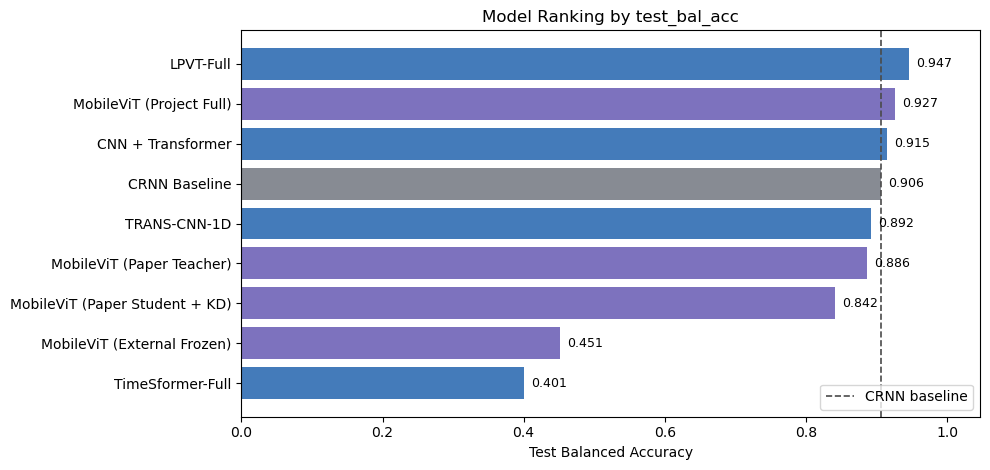

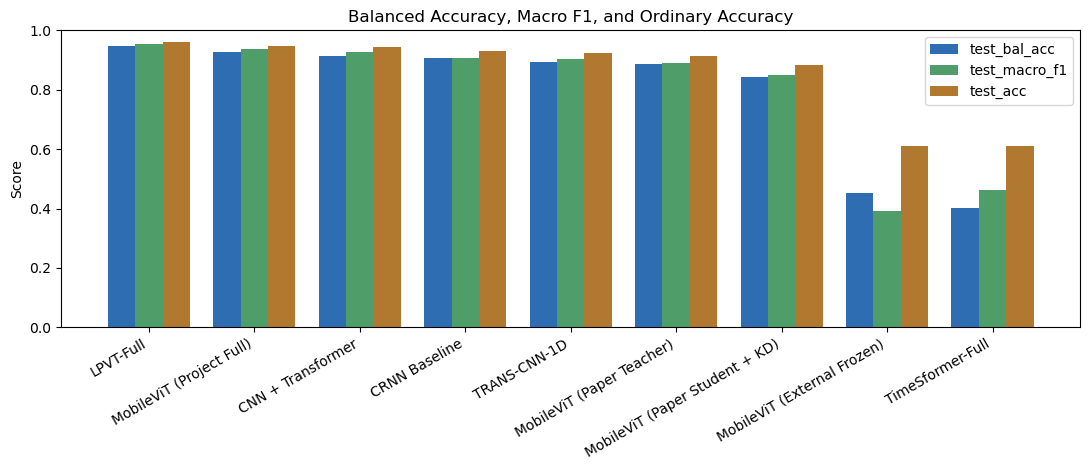

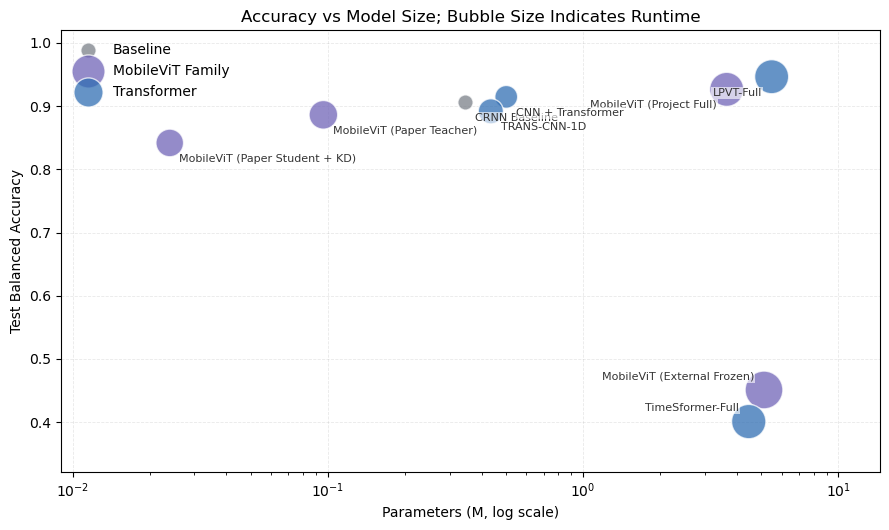

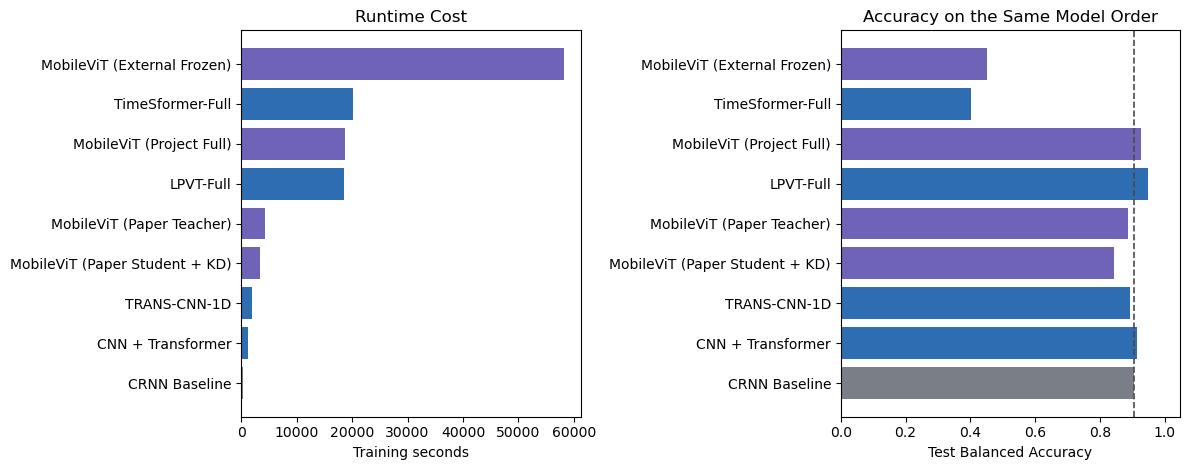

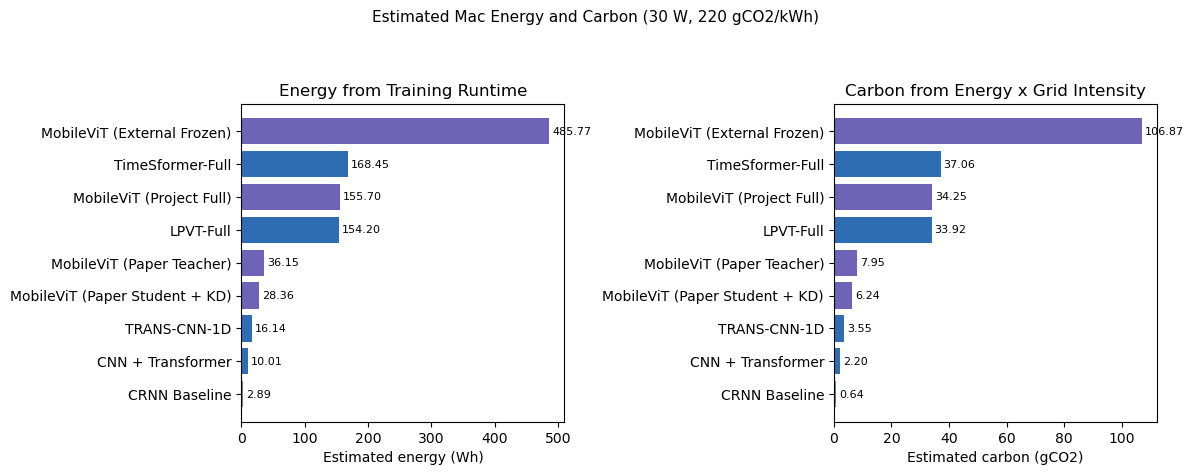

Per-class recall heatmap values


,Clockwise,Counterclockwise,Pull,Push,SlideLeft,SlideRight,n
LPVT-Full,1.000,0.996,0.887,0.931,0.905,0.924,0.983
MobileViT (Project Full),0.996,1.000,0.862,0.905,0.822,0.916,0.984
CNN + Transformer,1.000,0.971,0.822,0.858,0.858,0.902,0.992
CRNN Baseline,0.905,0.989,0.887,0.836,0.887,0.869,0.969
TRANS-CNN-1D,0.960,0.960,0.855,0.775,0.851,0.862,0.981
MobileViT (Paper Teacher),0.982,0.982,0.782,0.767,0.847,0.884,0.961
MobileViT (Paper Student + KD),0.978,0.920,0.775,0.698,0.753,0.815,0.954
MobileViT (External Frozen),0.175,0.731,0.713,0.629,0.000,0.022,0.887
TimeSformer-Full,0.276,0.102,0.327,0.331,0.393,0.407,0.970


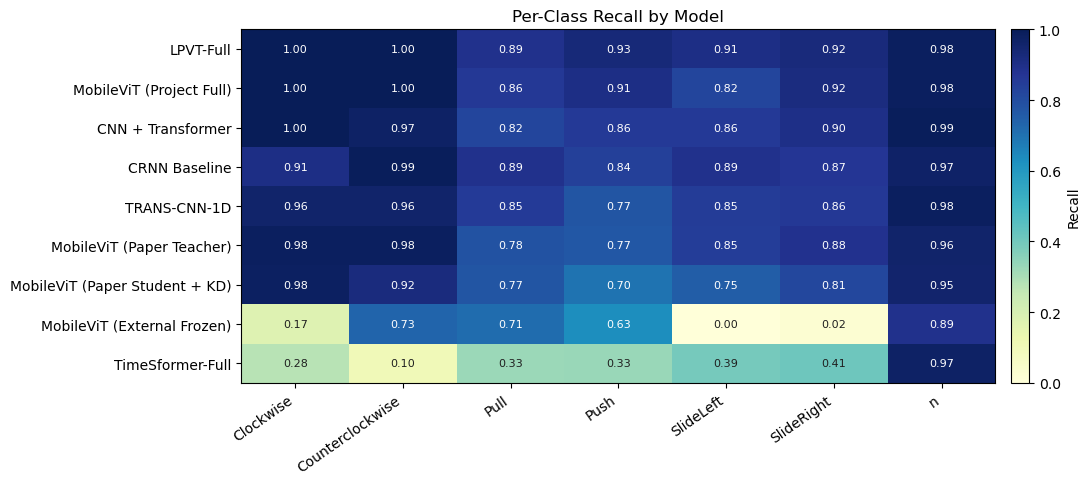

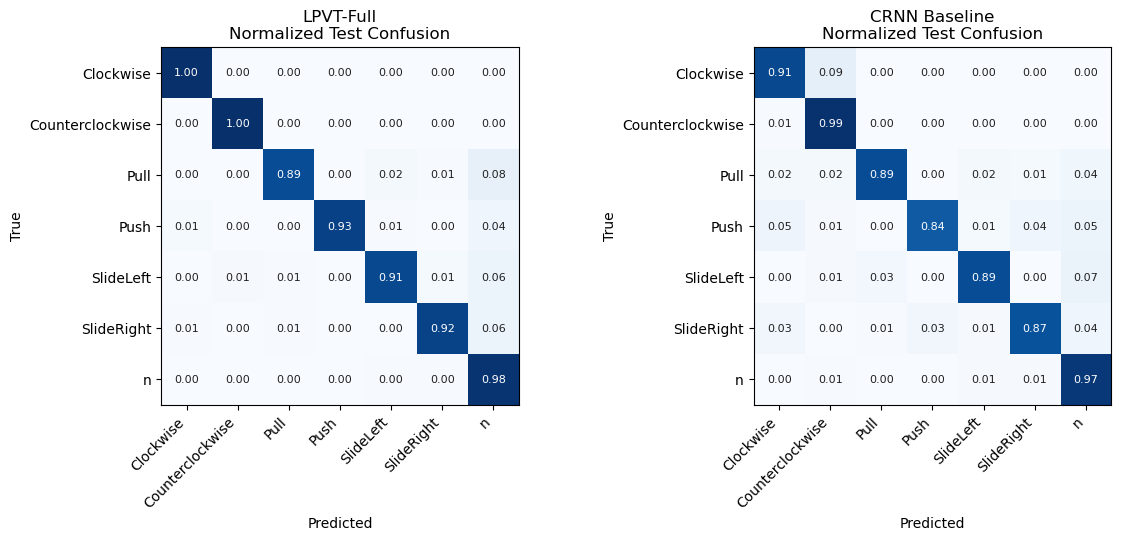

In [26]:
# Plot ranking, metric comparison, runtime tradeoff, per-class recall, and confusion matrices.
PER_CLASS_RECALL_DF = plot_result_figures(
    RESULTS_DF,
    TEST_DETAILS,
    config=CONFIG,
    label_encoder=label_encoder,
    failed_models=FAILED_MODELS,
)
